## Code to reproduce the reconstruction and figures from the manuscript

**"3D Reconstruction and Vertical Velocity Decomposition of an Intrathermocline Eddy from SWOT Altimetry"**

***
### Author: Elisabet Verger-Miralles, IMEDEA (CSIC-UIB)
### August 2026

This notebook reproduces Figures 1-7 of the manuscript from the raw glider, CTD, ADCP and SWOT L3
observations. It is organized in four parts: (1) libraries, (2) configuration, (3) core functions
and (4) the data-loading / reconstruction pipeline, followed by (5) the figure-generation cells.

Only the calculations strictly required to reproduce the published figures are included.

## 1. Libraries

In [1]:
# ==============================================================
# LIBRARIES
# ==============================================================
import os
import math
import warnings
from datetime import datetime

import numpy as np
import xarray as xr
import gsw
import scipy.io
from scipy.ndimage import gaussian_filter, generic_filter
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.spatial import cKDTree, Delaunay
from scipy.interpolate import griddata, interp1d, LinearNDInterpolator, PchipInterpolator
from scipy.signal import butter, filtfilt
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator, MultipleLocator
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

from seabird.cnv import fCNV

c:\Users\ASUS\anaconda3\envs\env_elisabet\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. Configuration

Edit the paths below to point to your local copy of the data (see `README.md` for the expected
layout and the data-availability statement). All other parameters are the final choices used in
the manuscript.

In [ ]:
# ==============================================================
# CONFIGURATION — local paths (Elisabet's machine).
# Before publishing to GitHub, swap this block back to relative data/
# paths (see README.md) so the repo is portable for other users.
# ==============================================================

# --- data directories (original working-copy locations) ---
DIR_GLIDER            = '.../Data/gliders/'
GLIDER_SECTION4_FILE  = '.../Data/gliders/dep0007_sdeep09_scb-sldeep009_L2_2023-04-25_data_dt.nc'
DIR_SWOT              = '.../Data/SWOT/SWOT_data_L3/v3/'
DIR_CTD_LEG1          = '.../Data/CTD/CTD_data/leg1/HM'
ADCP_LEG1             = '.../Data/ADCP/ADCP_OS150_FaSt-SWOT_LEG1_V3.nc'

DIR_FIGURES = '.../figures/'
os.makedirs(DIR_FIGURES, exist_ok=True)

# --- SWOT day used for Figs. 1-3, 6, 7 (index into the sorted file list in DIR_SWOT) ---
SWOT_FILE_INDEX = 14

# --- glider time window used to build the EOF basis ---
GLIDER_START = datetime(2023, 4, 28, 9, 0)
GLIDER_END   = datetime(2023, 5, 7, 7, 38)

# --- glider Section 4 window (oxygen / chlorophyll / spiciness / w sampling — Figs. 1, 6) ---
SECTION4_START = np.datetime64(datetime(2023, 5, 3, 15, 39))
SECTION4_END   = np.datetime64(datetime(2023, 5, 7, 7, 4))

# --- spatial subdomain (eddy box) ---
LONMIN, LONMAX = 1.25, 1.95
LATMIN, LATMAX = 39.45, 40.25

# --- reconstruction / solver parameters (final paper configuration) ---
P_REF       = 700.0                  # dbar, dynamic-height reference level
P_GRID      = np.arange(0, 701, 5)   # dbar, common vertical grid
FWHM_KM     = 8.0                    # km, horizontal Gaussian filter applied to SSH/DH before differentiation
G           = 9.81                   # m s-2
OMEGA_EARTH = 7.2921159e-5           # s-1

# depths (m) at which sigma0 / Ro / w_fg are mapped in Fig. 3
Z_LEVELS_FIG3 = [100, 300, 500]

# CTD casts used for the T6 (Leg 1) validation transect — Fig. 4
CTD_NAMES_L1T6 = ['dstation_02.cnv', 'dstation_03.cnv', 'dstation_04.cnv', 'dstation_05.cnv']

# T6 ADCP transect id and SWOT day (26 Apr 2023) used for the CTD/ADCP validation — Figs. 4, 5
T6_TRANSECT_ID  = 6
T6_SWOT_DATE    = '20230426'

## 3. Core functions

Grouped by purpose: CTD I/O, the omega-equation solver (final SSH-filtering method), the Rossby
number diagnostic, ADCP I/O and cross-track projection, the per-day full reconstruction, and the
natural-coordinate omega-equation inversion used for the Q-vector decomposition.

In [3]:
# ---------------------------------------------------------------
# CTD I/O (Seabird .cnv casts -> sigma0 on a common pressure grid)
# ---------------------------------------------------------------
def find_file(directory, basename):
    for candidate in [basename, basename + '.cnv', basename.replace('.cnv', '') + '.cnv']:
        full = os.path.join(directory, candidate)
        if os.path.exists(full):
            return full
    raise FileNotFoundError(f"Cannot find {basename} in {directory}")


def get_column_safe(ctd, possible_names):
    for name in possible_names:
        if name in ctd.keys():
            return ctd[name]
    raise KeyError(f"No column found among {possible_names}")


def load_ctd_profiles(directory, names, p_target):
    """Load a list of Seabird .cnv CTD casts, compute sigma0 (TEOS-10),
    and interpolate each profile onto p_target (dbar).

    Returns (sigma0_profiles [n, nz], lon [n], lat [n])."""
    sigma0_profiles, lons, lats = [], [], []
    for name in names:
        fpath = find_file(directory, name)
        ctd = fCNV(fpath)
        pres = get_column_safe(ctd, ['PRDM', 'PRES', 'CTDPRS'])
        temp = get_column_safe(ctd, ['TEMP', 'CTDTMP'])
        sal  = get_column_safe(ctd, ['PSAL', 'CTDSAL'])
        m = (~np.isnan(pres)) & (~np.isnan(temp)) & (~np.isnan(sal))
        pres, temp, sal = pres[m], temp[m], sal[m]

        SA = gsw.SA_from_SP(sal, pres, ctd.attributes['LONGITUDE'], ctd.attributes['LATITUDE'])
        CT = gsw.CT_from_t(SA, temp, pres)
        sigma0 = gsw.rho(SA, CT, 0) - 1000.0

        sigma0_profiles.append(np.interp(p_target, pres, sigma0, left=np.nan, right=np.nan))
        lons.append(ctd.attributes['LONGITUDE'])
        lats.append(ctd.attributes['LATITUDE'])
    return np.array(sigma0_profiles), np.array(lons), np.array(lats)

In [ ]:
# ---------------------------------------------------------------
# Omega-equation solver (QG):
#   d/dz( f0^2 dw/dz ) + N^2 laplacian_h(w) = 2 div(Q)
#   discretised as (M2 - K^2 M1) w_hat = rhs_hat in horizontal Fourier space.
# Final paper pipeline: SSH/DH filtered horizontally (FWHM_KM) BEFORE any
# spatial differentiation, so geostrophic u, v, b are consistent with w_fg.
# Solver courtesy of Weiguang Wu (MIT, WHOI)
# ---------------------------------------------------------------
def smooth2d(field3D, FWHM_km, dx_m, dy_m, mode="nearest"):
    """NaN-aware Gaussian filter (given FWHM in km) applied per vertical level."""
    dx_m, dy_m = abs(dx_m), abs(dy_m)
    sigma_km = FWHM_km / 2.355
    sigx = sigma_km * 1000 / dx_m
    sigy = sigma_km * 1000 / dy_m

    out = np.empty_like(field3D, dtype=float)
    for k in range(field3D.shape[0]):
        A  = field3D[k].astype(float)
        M  = np.isfinite(A).astype(float)
        A0 = np.where(np.isfinite(A), A, 0.0)
        num = gaussian_filter(A0, sigma=(sigy, sigx), mode=mode)
        den = gaussian_filter(M,  sigma=(sigy, sigx), mode=mode)
        out[k] = np.where(den > 1e-12, num / den, np.nan)
    return out


def compute_wfg(FWHM_km, DH3D_an, rho_ref_3d, g_surface, f0,
                 p_valid, dx, dy, M1, M2, depth, g=G):
    """
    Filter DH horizontally -> geostrophic u, v + buoyancy b -> Q-vector
    divergence -> solve the omega equation.

    Returns
    -------
    w_fg : (nz-2, ny-2, nx-2)   QG vertical velocity [m s-1]
    u_f, v_f, b_f : (nz, ny, nx) filtered dynamical fields
    """
    # --- filter DH, build geostrophic velocities (z, y, x) ---
    DH_zyx   = np.transpose(DH3D_an, (2, 0, 1))
    DH_zyx_f = smooth2d(DH_zyx, FWHM_km, dx, dy)

    dDH_dy = np.gradient(DH_zyx_f, axis=1) / dy
    dDH_dx = np.gradient(DH_zyx_f, axis=2) / dx
    u_f = -g_surface / f0 * dDH_dy
    v_f =  g_surface / f0 * dDH_dx

    # --- density / buoyancy from the filtered DH ---
    DH_f      = np.transpose(DH_zyx_f, (1, 2, 0))
    p_pa      = np.asarray(p_valid, dtype=float) * 1e4
    dDH_dp    = np.gradient(DH_f, p_pa, axis=2)
    delta_nu  = -g * dDH_dp
    delta_rho = -(rho_ref_3d ** 2) * delta_nu
    rho_f     = rho_ref_3d + delta_rho
    b_latlonp = -g * (rho_f - rho_ref_3d) / rho_ref_3d
    b_f       = np.transpose(b_latlonp, (2, 0, 1))

    # --- Q-vector and its divergence ---
    b_x = np.gradient(b_f, axis=2) / dx
    b_y = np.gradient(b_f, axis=1) / dy
    u_x = np.gradient(u_f, axis=2) / dx
    u_y = np.gradient(u_f, axis=1) / dy
    v_x = np.gradient(v_f, axis=2) / dx
    v_y = np.gradient(v_f, axis=1) / dy

    Q_x = -2.0 * (u_x * b_x + v_x * b_y)
    Q_y = -2.0 * (u_y * b_x + v_y * b_y)
    Q_div = ((Q_x[:, 1:-1, 2:] - Q_x[:, 1:-1, :-2]) / (2.0 * dx) +
             (Q_y[:, 2:, 1:-1] - Q_y[:, :-2, 1:-1]) / (2.0 * dy))

    F = Q_div.copy()
    F[~np.isfinite(F)] = 0.0
    w_fg = invert_omega(F, dx, dy, depth, M1, M2)
    return w_fg, u_f, v_f, b_f


def invert_omega(F, dx, dy, depth, M1, M2):
    """Invert the discretised omega equation (M2 - K^2 M1) w_hat = rhs_hat
    for a horizontal forcing field F, using mirror padding for a
    pseudo-periodic FFT and per-wavenumber vertical solves. Returns w on
    the original (unpadded) horizontal grid.

    F may be given either on the FULL vertical grid (nz levels, as in the
    main solver compute_wfg -- the top/bottom level is then dropped to
    match M1/M2, which are built on the nz-2 interior levels) or already
    on the INTERIOR grid (nz-2 levels, as in the Q-vector natural-coordinate
    decomposition, where each term is assembled directly on nz-2 levels)."""
    nz_F, ny_i, nx_i = F.shape
    F2 = np.append(F,  F[:, :, ::-1], axis=2)
    F4 = np.append(F2, F2[:, ::-1, :], axis=1)
    nz_p, ny_p, nx_p = F4.shape
    fft_rhs = np.fft.fft2(F4, axes=(1, 2))

    k_n = 1.0 / (2.0 * abs(dx)); l_n = 1.0 / (2.0 * abs(dy))
    k1 = np.linspace(0.0, k_n, num=int(nx_p / 2) + 1)
    k  = 2.0 * np.pi * np.append(k1[:-1], -k1[::-1][:-1])
    l1 = np.linspace(0.0, l_n, num=int(ny_p / 2) + 1)
    l  = 2.0 * np.pi * np.append(l1[:-1], -l1[::-1][:-1])
    k2d, l2d = np.meshgrid(k, l)

    ln = len(depth)
    if nz_F == ln:
        z_lo, z_hi = 1, nz_F - 1          # F on the full grid -> drop top/bottom level
    elif nz_F == ln - 2:
        z_lo, z_hi = 0, nz_F              # F already on the interior (nz-2) grid
    else:
        raise ValueError(f"Vertical mismatch: nz_F={nz_F} vs depth levels={ln}")

    w_fft = np.zeros((z_hi - z_lo, ny_p, nx_p), dtype=complex)
    for i in range(nx_p):
        for j in range(ny_p):
            K2 = k2d[j, i] ** 2 + l2d[j, i] ** 2
            if K2 == 0.0:
                continue
            A = M2 - K2 * M1
            w_fft[:, j, i] = spsolve(A, fft_rhs[z_lo:z_hi, j, i])

    w1 = np.real(np.fft.ifft2(w_fft, axes=(1, 2)))
    return w1[:, :ny_i, :nx_i]

In [5]:
# ---------------------------------------------------------------
# Rossby number on the interior grid (centered horizontal derivatives
# leave a 1-pixel border undefined)
# ---------------------------------------------------------------
def rossby_filtered(u3d, v3d, dx, dy, depth, z_target, lat2d):
    iz = np.argmin(np.abs(depth - z_target))
    u_y = np.gradient(u3d, axis=1) / dy
    v_x = np.gradient(v3d, axis=2) / dx
    zeta = (v_x[iz] - u_y[iz])[1:-1, 1:-1]     # interior domain
    f0 = 2 * OMEGA_EARTH * np.sin(np.deg2rad(np.nanmean(lat2d)))
    return zeta / f0

In [6]:
# ---------------------------------------------------------------
# ADCP I/O and cross-track validation helpers
# ---------------------------------------------------------------
def load_adcp_transect(path, tid):
    ds = xr.open_dataset(path)
    ds_tr = ds.where(ds.transect_id == tid, drop=True)
    lon = np.asarray(ds_tr['lon'].values, float)
    lat = np.asarray(ds_tr['lat'].values, float)
    dep = np.asarray(ds_tr['depth'].values, float)
    u   = np.asarray(ds_tr['u'].values, float)
    v   = np.asarray(ds_tr['v'].values, float)
    if u.ndim == 2 and u.shape[0] != lon.size and u.shape[1] == lon.size:
        u, v = u.T, v.T
    # sort along the dominant axis
    if (lon.max() - lon.min()) >= (lat.max() - lat.min()):
        order = np.argsort(lon)
    else:
        order = np.argsort(lat)
    return dict(lon=lon[order], lat=lat[order], depth=dep,
                u=u[order, :], v=v[order, :])


def project_recon_to_transect(rec, adcp):
    """Nearest-neighbour projection of reconstructed u, v onto the ADCP
    positions and depths. Triangulation-free, fully vectorized."""
    lon_a = np.asarray(adcp['lon'], float)
    lat_a = np.asarray(adcp['lat'], float)
    depth_a = np.asarray(adcp['depth'], float)
    zpos = np.asarray(rec['depth'], float)

    u3d = rec['u_geo']            # (ny, nx, nz)
    v3d = rec['v_geo']
    ny, nx, nz = u3d.shape

    pts = np.column_stack((rec['lat_swot'].ravel(), rec['lon_swot'].ravel()))
    tree = cKDTree(pts)
    _, idx = tree.query(np.column_stack((lat_a, lon_a)))   # (n_along,)

    u_col = u3d.reshape(-1, nz)[idx]
    v_col = v3d.reshape(-1, nz)[idx]

    iz = np.abs(zpos[None, :] - depth_a[:, None]).argmin(axis=1)   # (ndepth,)
    Ug = u_col[:, iz]    # (n_along, ndepth)
    Vg = v_col[:, iz]
    return Ug, Vg


def cross_track(u, v, lon, lat):
    """Project (u, v) onto the unit vector perpendicular to the transect line."""
    dlon = (lon[-1] - lon[0]) * np.cos(np.deg2rad(np.nanmean(lat)))
    dlat = lat[-1] - lat[0]
    ang = np.arctan2(dlat, dlon)
    nx, ny = -np.sin(ang), np.cos(ang)
    return u * nx + v * ny


def adcp_recon_metrics(A, R, depth, dmin=30.0, dmax=400.0):
    md = (depth >= dmin) & (depth <= dmax)
    a, r = A[:, md], R[:, md]
    m = np.isfinite(a) & np.isfinite(r)
    if m.sum() < 30:
        return np.nan, np.nan
    return np.sqrt(np.mean((r[m] - a[m]) ** 2)), np.corrcoef(a[m], r[m])[0, 1]

In [7]:
# ---------------------------------------------------------------
# Per-day full 3-D reconstruction (reuses the fixed EOF basis) and helpers
# to sample it at CTD positions.
# ---------------------------------------------------------------
def reconstruct_day_full(path):
    """Full reconstruction for an arbitrary SWOT file. ADT is smoothed to
    FWHM_KM before any spatial differentiation, exactly as in compute_wfg,
    so geostrophy is consistent with the paper. Returns a dict with
    sigma0_recon (ny, nx, nz), u_geo, v_geo (ny, nx, nz), lon_swot,
    lat_swot (2-D), adt_anom (ny, nx), depth, f0."""
    ds = xr.open_dataset(path)
    ds = ds.where(
        (ds['longitude'] < LONMAX) & (ds['longitude'] > LONMIN) &
        (ds['latitude']  < LATMAX) & (ds['latitude']  > LATMIN),
        drop=True).load()

    lon_s = ds['longitude'].values
    lat_s = ds['latitude'].values
    if lat_s.size == 0 or np.all(np.isnan(lat_s)):
        raise RuntimeError("SWOT pass does not cover the box this day")

    adt      = ds['ssha_filtered'].values + ds['mdt'].values
    adt_anom = adt - np.nanmean(adt)

    lat_vec = lat_s[:, 0] if lat_s.ndim == 2 else lat_s
    lon_vec = lon_s[0, :] if lon_s.ndim == 2 else lon_s
    lat_m   = float(np.nanmean(lat_vec))
    f0d = 2 * OMEGA_EARTH * np.sin(np.deg2rad(lat_m))
    g_s = gsw.grav(lat_m, 0.0)
    depth_d = -gsw.z_from_p(p_valid, lat_m)
    dx = np.mean(np.diff(lon_vec)) * 111e3 * np.cos(np.deg2rad(lat_m))
    dy = np.mean(np.diff(lat_vec)) * 111e3

    adt_f = smooth2d(adt_anom[None, :, :], FWHM_KM, dx, dy)[0]   # (ny, nx)

    A1 = adt_f / EOF1_surface
    DH3D = A1[..., None] * EOFs[0]                       # (ny, nx, nz)

    p_pa = p_valid * 1e4
    dDH_dp    = np.gradient(DH3D, p_pa, axis=2)
    delta_nu  = -G * dDH_dp
    delta_rho = -(rho_ref_3d ** 2) * delta_nu
    sigma0_r  = (rho_ref_3d + delta_rho) - 1000.0

    Phi = g_s * DH3D
    y_m = (lat_vec - lat_vec[0]) * 111e3
    x_m = (lon_vec - lon_vec[0]) * 111e3 * np.cos(np.deg2rad(lat_m))
    dPhidy = np.gradient(Phi, y_m, axis=0)
    dPhidx = np.gradient(Phi, x_m, axis=1)
    u_geo = -(1.0 / f0d) * dPhidy
    v_geo =  (1.0 / f0d) * dPhidx

    if lon_s.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon_s, lat_s)
    else:
        lon2d, lat2d = lon_s, lat_s

    return dict(sigma0_recon=sigma0_r, u_geo=u_geo, v_geo=v_geo,
                lon_swot=lon2d, lat_swot=lat2d, adt_anom=adt_anom,
                depth=depth_d, f0=f0d, lon_vec=lon_vec, lat_vec=lat_vec)


def find_swot_file(date_yyyymmdd):
    import glob
    matches = sorted(glob.glob(
        DIR_SWOT + f"SWOT_L3_LR_SSH_Expert_*_016_*_{date_yyyymmdd}T*.nc"))
    if not matches:
        raise FileNotFoundError(f"No SWOT pass-016 file for {date_yyyymmdd}")
    return matches[0]


def sample_recon_at(rec, lon_pts, lat_pts, p_target):
    tree = cKDTree(np.c_[rec['lon_swot'].ravel(), rec['lat_swot'].ravel()])
    _, idx = tree.query(np.c_[lon_pts, lat_pts])
    return rec['sigma0_recon'].reshape(-1, len(p_target))[idx]

## 4. Directories & data import — build the reconstruction

Runs the full pipeline once: glider EOF basis -> SWOT projection -> omega-equation solve
(final FWHM = 8 km SSH-filtering method) -> per-day (26 Apr / T6) reconstruction -> CTD/ADCP
sampling -> glider Section-4 tracer sections -> Q-vector natural-coordinate decomposition.
All variables produced here are reused directly by the figure cells in Section 5.

### 4.1 Glider dynamic height and EOF basis

In [8]:
# --- 1a. load glider, select the EOF time window ---
mat = scipy.io.loadmat(DIR_GLIDER + 'DH_Elisabet.mat')

lon09  = mat['sp09']['lon_dh'][0, 0][0]
lat09  = mat['sp09']['lat_dh'][0, 0][0]
time09 = mat['sp09']['time_dh'][0, 0][0]
# MATLAB datenum -> python datetime
from datetime import timedelta as _timedelta
time09 = np.array([datetime.fromordinal(int(d)) + _timedelta(days=d % 1)
                   - _timedelta(days=366) for d in time09])

p09     = mat['sp09']['pr_dh'][0, 0].T
depth09 = mat['sp09']['depth_dh'][0, 0].T
CT_all  = mat['sp09']['CT_dh'][0, 0].T
SA_all  = mat['sp09']['s_dh'][0, 0].T     # already Absolute Salinity in this file

sel = (time09 > np.datetime64(GLIDER_START)) & (time09 < np.datetime64(GLIDER_END))
Lon09, Lat09 = lon09[sel], lat09[sel]
P, Depth09   = p09[sel], depth09[sel]
CT, SA       = CT_all[sel], SA_all[sel]
time09       = time09[sel]

print(f"Selected {sel.sum()} glider profiles ({time09.min()} -> {time09.max()})")

# --- 1b. interpolate T/S to a common pressure grid, compute dynamic height ---
n_profiles = SA.shape[0]
SAi = np.full((n_profiles, P_GRID.size), np.nan)
CTi = np.full((n_profiles, P_GRID.size), np.nan)

for i in range(n_profiles):
    m = ~np.isnan(SA[i]) & ~np.isnan(CT[i]) & ~np.isnan(P[i])
    if m.sum() > 3:
        SAi[i] = np.interp(P_GRID, P[i, m], SA[i, m])
        CTi[i] = np.interp(P_GRID, P[i, m], CT[i, m])

dyn_height = np.full_like(SAi, np.nan)
for i in range(n_profiles):
    m = ~np.isnan(SAi[i]) & ~np.isnan(CTi[i])
    if m.sum() > 3:
        dyn_height[i, m] = gsw.geo_strf_dyn_height(SAi[i, m], CTi[i, m], P_GRID[m], P_REF)

g_surface    = gsw.grav(float(np.nanmean(Lat09)), 0.0)
dyn_height_m = dyn_height / g_surface   # geopotential anomaly -> metres

# --- 2. PCA / EOF decomposition of dynamic height ---
mask    = ~np.isnan(dyn_height_m).all(axis=0)
p_valid = P_GRID[mask]
X       = dyn_height_m[:, mask]
X       = X[~np.isnan(X).any(axis=1), :]

mean_level = X.mean(axis=0)
X_anom     = X - mean_level

pca      = PCA()
PCs      = pca.fit_transform(X_anom)
EOFs     = pca.components_
explained = pca.explained_variance_ratio_ * 100
print("Explained variance (%):", explained[:3])

Selected 179 glider profiles (2023-04-28 13:41:16.995966 -> 2023-05-07 06:33:06.024553)
Explained variance (%): [97.81512014  1.47788895  0.54162356]


### 4.2 SWOT L3 loading, EOF1 projection and sigma0 reconstruction

In [9]:
# --- 3. load SWOT L3, subset to the eddy box, build the ADT anomaly ---
swot_files = sorted(f for f in os.listdir(DIR_SWOT) if f.endswith('.nc'))
file_swot  = swot_files[SWOT_FILE_INDEX]
print("SWOT file:", file_swot)

ds_SWOT = xr.open_dataset(DIR_SWOT + file_swot)
ds_SWOT = ds_SWOT.where(
    (ds_SWOT['longitude'] < LONMAX) & (ds_SWOT['longitude'] > LONMIN) &
    (ds_SWOT['latitude']  < LATMAX) & (ds_SWOT['latitude']  > LATMIN),
    drop=True).load()

lat_swot = ds_SWOT['latitude'].values
lon_swot = ds_SWOT['longitude'].values
adt      = ds_SWOT['ssha_filtered'].values + ds_SWOT['mdt'].values
adt_anom = adt - np.nanmean(adt)

# --- 4a. project EOF1 amplitude onto SWOT -> 3-D DH anomaly ---
idx0         = np.argmin(np.abs(p_valid - 0.0))   # surface index
EOF1_surface = EOFs[0, idx0]
A1           = adt_anom / EOF1_surface            # (ny, nx) amplitude
DH3D_an      = A1[..., None] * EOFs[0, :]          # (ny, nx, nz)  [m]

# --- 4b. DH (m) -> sigma0 anomaly (specific-volume / hydrostatic) ---
p_pa = p_valid * 1e4                              # dbar -> Pa

SA_ref = np.nanmean(SAi[:, np.isin(P_GRID, p_valid)], axis=0)
CT_ref = np.nanmean(CTi[:, np.isin(P_GRID, p_valid)], axis=0)
rho_ref    = gsw.rho(SA_ref, CT_ref, 0)           # kg m-3 at p=0
rho_ref_3d = rho_ref[None, None, :]               # (1, 1, nz)

dDH_dp    = np.gradient(DH3D_an, p_pa, axis=2)     # m/Pa
delta_nu  = -G * dDH_dp
delta_rho = -(rho_ref_3d ** 2) * delta_nu
rho_recon    = rho_ref_3d + delta_rho
sigma0_recon = rho_recon - 1000.0                  # (ny, nx, nz)

SWOT file: SWOT_L3_LR_SSH_Expert_511_016_20230505T050152_20230505T055256_v3.0.nc


### 4.3 Grid metrics, stratification and the omega-equation solve (final FWHM = 8 km)

In [10]:
# --- 5a. grid metrics, Coriolis, depth axis ---
lat_vec = lat_swot[:, 0] if lat_swot.ndim == 2 else lat_swot
lon_vec = lon_swot[0, :] if lon_swot.ndim == 2 else lon_swot
lat_mean = float(np.nanmean(lat_vec))

f0 = 2 * OMEGA_EARTH * np.sin(np.deg2rad(lat_mean))
dx = np.mean(np.diff(lon_vec)) * 111e3 * np.cos(np.deg2rad(lat_mean))
dy = np.mean(np.diff(lat_vec)) * 111e3
depth = -gsw.z_from_p(p_valid, lat_mean)   # (nz,), positive-down

# --- 5b. stratification N^2(z) and vertical operators M1, M2 ---
N2_prof, _ = gsw.Nsquared(SA_ref, CT_ref, p_valid, lat_mean)
N2_prof    = np.clip(N2_prof, 1e-6, None)          # remove noise-driven negatives

zc  = depth.copy()
dzc = zc[1:] - zc[:-1]
dzf = 0.5 * (dzc[1:] + dzc[:-1])

M1 = diags(N2_prof[:-1]).todense()

l_diag = f0**2 / dzc[1:-1] / dzf[1:]
r_diag = f0**2 / dzc[1:-1] / dzf[:-1]
diag_mid = (-f0**2 / dzc[1:-2] / dzf[1:-1]
            - f0**2 / dzc[2:-1] / dzf[1:-1])
ul = -f0**2 / dzc[1] / dzf[0] - f0**2 / dzc[0]  / dzf[0]
lr = -f0**2 / dzc[-1] / dzf[-1] - f0**2 / dzc[-2] / dzf[-1]
diag = np.hstack([ul, diag_mid, lr])
M2 = diags((l_diag, diag, r_diag), offsets=(-1, 0, 1)).todense()

# --- solve the omega equation with the paper's final method: SSH/DH
#     filtered horizontally (FWHM_KM) BEFORE any spatial differentiation ---
w_fg, u, v, b = compute_wfg(FWHM_KM, DH3D_an, rho_ref_3d, g_surface, f0,
                            p_valid, dx, dy, M1, M2, depth)
w_fg_filtered_raw = w_fg   # kept for the Q-vector decomposition consistency check
print(f"omega equation solved (FWHM = {FWHM_KM:.0f} km): w_fg shape = {w_fg.shape}")

# --- Rossby number diagnostic + interior grid coordinates shared by all maps ---
lon_i = lon_swot[1:-1, 1:-1]
lat_i = lat_swot[1:-1, 1:-1]
ssh_i = adt_anom[1:-1, 1:-1] * 100             # cm
swot_mask = np.isfinite(ssh_i)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31424\1513017071.py:22: RuntimeWarning: invalid value encountered in divide
  out[k] = np.where(den > 1e-12, num / den, np.nan)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_31424\1513017071.py:114: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  w_fft[:, j, i] = spsolve(A, fft_rhs[z_lo:z_hi, j, i])


omega equation solved (FWHM = 8 km): w_fg shape = (139, 48, 35)


### 4.4 CTD stations (Leg 1, transect T6) — Fig. 4 validation

In [11]:
sigma0_L1T6, lon_L1T6, lat_L1T6 = load_ctd_profiles(DIR_CTD_LEG1, CTD_NAMES_L1T6, p_valid)
lon_ctd_list, lat_ctd_list = list(lon_L1T6), list(lat_L1T6)   # station overlay in Fig. 1
n_T6 = len(CTD_NAMES_L1T6)
print(f"Loaded {n_T6} CTD casts for transect T6")

Loaded 4 CTD casts for transect T6


### 4.5 Per-day reconstruction for T6 (26 Apr 2023) + CTD/ADCP sampling — Figs. 4, 5

In [12]:
# full 3-D reconstruction for the T6 validation day (reuses the fixed EOF basis)
rec_T6 = reconstruct_day_full(find_swot_file(T6_SWOT_DATE))
print("reconstructed 26-Apr (T6)")

# sample the reconstruction at the 4 CTD positions
sig_rec_L1T6 = sample_recon_at(rec_T6, lon_L1T6, lat_L1T6, p_valid)

# load the T6 ADCP transect and its cross-track validation
adcp_T6 = load_adcp_transect(ADCP_LEG1, T6_TRANSECT_ID)

reconstructed 26-Apr (T6)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31424\1513017071.py:22: RuntimeWarning: invalid value encountered in divide
  out[k] = np.where(den > 1e-12, num / den, np.nan)


### 4.6 Glider Section 4: oxygen, chlorophyll, sigma0, spiciness (SA/CT-based) — Figs. 1, 6

In [13]:
ds_glider_oxy = xr.open_dataset(GLIDER_SECTION4_FILE)

oxygen_conc     = ds_glider_oxy['oxygen_concentration'].values
chlorophyll     = ds_glider_oxy['chlorophyll'].values          # mg m-3
time_glider     = ds_glider_oxy['time'].values
lat_glider      = ds_glider_oxy['latitude'].values
lon_glider      = ds_glider_oxy['longitude'].values
depth_glider    = ds_glider_oxy['depth'].values
pressure_glider = ds_glider_oxy['pressure'].values
PSAL_glider     = ds_glider_oxy['salinity'].values
TEMP_glider     = ds_glider_oxy['temperature'].values

nprof_f, nz_f = PSAL_glider.shape
LON2f = np.broadcast_to(lon_glider[:, None], (nprof_f, nz_f))
LAT2f = np.broadcast_to(lat_glider[:, None], (nprof_f, nz_f))
SA_glider = gsw.SA_from_SP(PSAL_glider, pressure_glider, LON2f, LAT2f)
CT_glider = gsw.CT_from_t(SA_glider, TEMP_glider, pressure_glider)
sigma0_glider = gsw.sigma0(SA_glider, CT_glider)        # SA-based

sel_oxy = (time_glider < SECTION4_END) & (time_glider > SECTION4_START)
oxygen_conc_sel   = oxygen_conc[sel_oxy]
chl_sel           = chlorophyll[sel_oxy]
lat_glider_sel    = lat_glider[sel_oxy]
lon_glider_sel    = lon_glider[sel_oxy]
sigma0_glider_sel = sigma0_glider[sel_oxy]

SA_glider_sel    = SA_glider[sel_oxy]
CT_glider_sel    = CT_glider[sel_oxy]
spice_glider_sel = gsw.spiciness0(SA_glider_sel, CT_glider_sel)

print("glider (SA) | sigma0", sigma0_glider_sel.shape,
      "| chl", round(float(np.nanmin(chl_sel)), 3), round(float(np.nanmax(chl_sel)), 3))

glider (SA) | sigma0 (65, 955) | chl 0.0 1.628


### 4.7 Sigma0 and w_QG sampled along the glider track — Figs. 1, 6

In [14]:
# --- sigma0 reconstructed along the real glider Section-4 track (2-D cKDTree) ---
lat_track = np.asarray(lat_glider_sel, dtype=float)
lon_track = np.asarray(lon_glider_sel, dtype=float)

sigma0_i = sigma0_recon[1:-1, 1:-1, :]          # (ny_i, nx_i, nz), same crop as the maps
ny_i, nx_i, nz = sigma0_i.shape

pts_grid = np.c_[lon_i.ravel(), lat_i.ravel()]
tree = cKDTree(pts_grid)
dist, idx_flat = tree.query(np.c_[lon_track, lat_track])
iy_g, ix_g = np.unravel_index(idx_flat, (ny_i, nx_i))
if np.nanmax(dist) > 0.05:
    print(f"  warning: some glider points are {np.nanmax(dist):.3f} deg from the nearest pixel")

sigma0_recon_section = sigma0_i[iy_g, ix_g, :].T          # (nz, n_track)

# --- w_QG along the same track (same cKDTree indices) ---
depth_grid = depth[1:-1]
w_glider_mday = w_fg[:, iy_g, ix_g] * 86400.0   # (nz-2, n_track), m/day
print("w_glider_mday", w_glider_mday.shape)

w_glider_mday (139, 65)


### 4.8 O2 and spice anomalies on isopycnal coordinates, vs w — Fig. 6

In [15]:
# ---- O2: bin onto a target sigma0 grid, profile by profile, then take the
#          along-isopycnal anomaly (removes the heave signal) ----
O2   = np.asarray(oxygen_conc_sel,  dtype=float)   # (nprof, nz_g)
SIG  = np.asarray(sigma0_glider_sel, dtype=float)  # (nprof, nz_g)
zg   = np.asarray(depth_glider, dtype=float)       # (nz_g,)
latg = np.asarray(lat_glider_sel, dtype=float)     # (nprof,)
nprof = O2.shape[0]

sigma_grid = np.arange(28.30, 29.16, 0.01)   # kg/m^3, covers the ITE core
nsig = len(sigma_grid)

O2_iso = np.full((nsig, nprof), np.nan)
z_iso  = np.full((nsig, nprof), np.nan)
for j in range(nprof):
    s, o, z = SIG[j, :], O2[j, :], zg
    m = np.isfinite(s) & np.isfinite(o)
    if m.sum() < 5:
        continue
    s_m, o_m, z_m = s[m], o[m], z[m]
    order = np.argsort(s_m)
    s_s, o_s, z_s = s_m[order], o_m[order], z_m[order]
    s_u, iu = np.unique(s_s, return_index=True)
    o_u, z_u = o_s[iu], z_s[iu]
    if len(s_u) < 5:
        continue
    O2_iso[:, j] = np.interp(sigma_grid, s_u, o_u, left=np.nan, right=np.nan)
    z_iso[:, j]  = np.interp(sigma_grid, s_u, z_u, left=np.nan, right=np.nan)

O2_ref_iso  = np.nanmean(O2_iso, axis=1)
O2_anom_iso = O2_iso - O2_ref_iso[:, None]

# ---- w reconstructed, projected to density coordinates (same sigma_grid) ----
w_iso = np.full((nsig, nprof), np.nan)
for j in range(nprof):
    s_prof = np.interp(depth_grid, zg, SIG[j, :], left=np.nan, right=np.nan)
    w_prof = w_glider_mday[:, j]
    m = np.isfinite(s_prof) & np.isfinite(w_prof)
    if m.sum() < 5:
        continue
    s_m, w_m = s_prof[m], w_prof[m]
    order = np.argsort(s_m)
    s_s, w_s = s_m[order], w_m[order]
    s_u, iu = np.unique(s_s, return_index=True)
    w_u = w_s[iu]
    if len(s_u) < 5:
        continue
    w_iso[:, j] = np.interp(sigma_grid, s_u, w_u, left=np.nan, right=np.nan)

# ---- spice: identical binning as O2 ----
# NOTE: loop variable deliberately NOT named v/u/b -- those are the global
# geostrophic velocity/buoyancy fields used later by the Q-vector
# decomposition (Sec. 4.9); shadowing them here at top level would silently
# overwrite the 3-D fields with a 1-D profile.
SP = np.asarray(spice_glider_sel, dtype=float)
spice_iso = np.full((nsig, nprof), np.nan)
for j in range(nprof):
    s, sp = SIG[j, :], SP[j, :]
    m = np.isfinite(s) & np.isfinite(sp)
    if m.sum() < 5:
        continue
    s_m, sp_m = s[m], sp[m]
    order = np.argsort(s_m)
    s_s, sp_s = s_m[order], sp_m[order]
    s_u, iu = np.unique(s_s, return_index=True)
    sp_u = sp_s[iu]
    if len(s_u) < 5:
        continue
    spice_iso[:, j] = np.interp(sigma_grid, s_u, sp_u, left=np.nan, right=np.nan)

spice_ref_iso  = np.nanmean(spice_iso, axis=1)
spice_anom_iso = spice_iso - spice_ref_iso[:, None]

print("binning:", O2_anom_iso.shape, spice_anom_iso.shape, w_iso.shape)

binning: (86, 65) (86, 65) (86, 65)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31424\3101376413.py:29: RuntimeWarning: Mean of empty slice
  O2_ref_iso  = np.nanmean(O2_iso, axis=1)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_31424\3101376413.py:70: RuntimeWarning: Mean of empty slice
  spice_ref_iso  = np.nanmean(spice_iso, axis=1)


### 4.9 Q_fg natural-coordinate decomposition (curvature / confluence / shear / along-stream) — Fig. 7

In [16]:
# Natural-coordinate decomposition of the frontogenetic Q-vector forcing.
# u, v, b are the fields already filtered at FWHM_KM by the solver above
# (compute_wfg) — they are NOT filtered again here.
eps = 1e-8

b_x = np.gradient(b, axis=2) / dx
b_y = np.gradient(b, axis=1) / dy
u_x = np.gradient(u, axis=2) / dx
u_y = np.gradient(u, axis=1) / dy
v_x = np.gradient(v, axis=2) / dx
v_y = np.gradient(v, axis=1) / dy

# total forcing (consistency reference)
Qx_tot = -2.0 * (u_x * b_x + v_x * b_y)
Qy_tot = -2.0 * (u_y * b_x + v_y * b_y)
F_tot = ((Qx_tot[:, 1:-1, 2:] - Qx_tot[:, 1:-1, :-2]) / (2 * dx) +
         (Qy_tot[:, 2:,   1:-1] - Qy_tot[:, :-2, 1:-1]) / (2 * dy))
F_tot[~np.isfinite(F_tot)] = 0.0

nz_u, ny_u, nx_u = u.shape
nz_i, ny_i, nx_i = nz_u - 2, ny_u - 2, nx_u - 2

F_alst = np.zeros((nz_i, ny_i, nx_i))
F_curv = np.zeros_like(F_alst)
F_shdv = np.zeros_like(F_alst)
F_crst = np.zeros_like(F_alst)

for k in range(1, nz_u - 1):
    kk = k - 1
    u0 = u[k]; v0 = v[k]
    U2 = u0**2 + v0**2
    U  = np.sqrt(U2 + eps)
    t_x = u0 / U; t_y = v0 / U

    b_s =  b_x[k] * t_x + b_y[k] * t_y
    b_n = -b_x[k] * t_y + b_y[k] * t_x

    div_alg = (u0**2 * u_x[k] + v0**2 * v_y[k] +
               u0 * v0 * u_y[k] + u0 * v0 * v_x[k]) / (U2 + eps)
    div_con = (u0**2 * v_y[k] + v0**2 * u_x[k] -
               u0 * v0 * u_y[k] - u0 * v0 * v_x[k]) / (U2 + eps)
    v_n     = (u0**2 * u_y[k] - v0**2 * v_x[k] -
               u0 * v0 * u_x[k] + u0 * v0 * v_y[k]) / (U2 + eps)
    vor_cur = (u0**2 * v_x[k] - v0**2 * u_y[k] -
               u0 * v0 * u_x[k] + u0 * v0 * v_y[k]) / (U2 + eps)

    Q_alst_s = -2.0 * div_alg * b_s
    Q_curv_s = -2.0 * vor_cur * b_n
    Q_shdv_n = -2.0 * v_n     * b_s
    Q_crst_n = -2.0 * div_con * b_n

    Q_alst_x = Q_alst_s * t_x;  Q_alst_y = Q_alst_s * t_y
    Q_curv_x = Q_curv_s * t_x;  Q_curv_y = Q_curv_s * t_y
    Q_shdv_x = -Q_shdv_n * t_y; Q_shdv_y =  Q_shdv_n * t_x
    Q_crst_x = -Q_crst_n * t_y; Q_crst_y =  Q_crst_n * t_x

    F_alst[kk] = ((Q_alst_x[1:-1, 2:] - Q_alst_x[1:-1, :-2]) / (2 * dx) +
                  (Q_alst_y[2:, 1:-1] - Q_alst_y[:-2, 1:-1]) / (2 * dy))
    F_curv[kk] = ((Q_curv_x[1:-1, 2:] - Q_curv_x[1:-1, :-2]) / (2 * dx) +
                  (Q_curv_y[2:, 1:-1] - Q_curv_y[:-2, 1:-1]) / (2 * dy))
    F_shdv[kk] = ((Q_shdv_x[1:-1, 2:] - Q_shdv_x[1:-1, :-2]) / (2 * dx) +
                  (Q_shdv_y[2:, 1:-1] - Q_shdv_y[:-2, 1:-1]) / (2 * dy))
    F_crst[kk] = ((Q_crst_x[1:-1, 2:] - Q_crst_x[1:-1, :-2]) / (2 * dx) +
                  (Q_crst_y[2:, 1:-1] - Q_crst_y[:-2, 1:-1]) / (2 * dy))

for Ftmp in (F_alst, F_curv, F_shdv, F_crst):
    Ftmp[~np.isfinite(Ftmp)] = 0.0

F_sum   = F_alst + F_curv + F_shdv + F_crst
F_tot_i = F_tot[1:-1]
print("Max |F_tot_i - F_sum| =", np.nanmax(np.abs(F_tot_i - F_sum)))   # ~0, sanity check

w_alst_fg = invert_omega(F_alst, dx, dy, depth, M1, M2)
w_curv_fg = invert_omega(F_curv, dx, dy, depth, M1, M2)
w_shdv_fg = invert_omega(F_shdv, dx, dy, depth, M1, M2)
w_crst_fg = invert_omega(F_crst, dx, dy, depth, M1, M2)

w_sum = w_alst_fg + w_curv_fg + w_shdv_fg + w_crst_fg
print("Max |w_fg - w_sum| =", np.nanmax(np.abs(w_fg - w_sum)))   # ~0, sanity check

# masked to the SWOT swath, used by the Fig. 7 map (300 m level)
z_target_fig7 = 300
iz_fig7 = np.argmin(np.abs(depth[1:-1] - z_target_fig7))
w_fg_filtered = np.where(swot_mask, w_fg, np.nan)
w_curv_fg     = np.where(swot_mask, w_curv_fg, np.nan)
w_crst_fg     = np.where(swot_mask, w_crst_fg, np.nan)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31424\1513017071.py:114: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  w_fft[:, j, i] = spsolve(A, fft_rhs[z_lo:z_hi, j, i])


Max |F_tot_i - F_sum| = 9.791858327176701e-20
Max |w_fg - w_sum| = 1.6914077702995765e-08


## 5. Figures

### Figure 1 — Context (ADT map + glider sigma0 section)

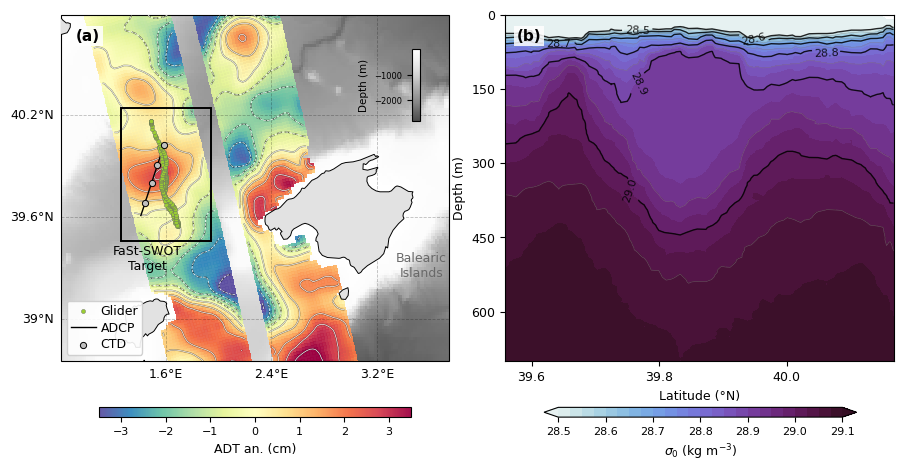

In [ ]:
# ==============================================================
# FIGURE 1: (a) ADT map (glider + T6 ADCP + CTDs) | (b) glider sigma0 section
# ==============================================================
lon_box_min, lon_box_max = LONMIN + 0.01, LONMAX - 0.01
lat_box_min, lat_box_max = LATMIN + 0.01, LATMAX - 0.01

# optional: NOAA ETOPO1 bathymetry (remote, requires internet); the map
# degrades gracefully (no shading) if this is unreachable.
FILE_BATHY = "https://www.ngdc.noaa.gov/thredds/dodsC/global/ETOPO1_Bed_g_gmt4.nc"
pc = ccrs.PlateCarree()

# ---- knobs (b) ----
SIGB_MIN, SIGB_MAX = 28.5, 29.1
fill_levels = np.linspace(28.5, 29.1, 25)
iso_major = np.round(np.arange(28.5, 29.1 + 0.001, 0.1), 2)
iso_minor = np.round(np.arange(28.55, 29.1 + 0.001, 0.1), 2)

# ---------------- data: ADT (full Balearic-scale box, for context) ----------------
ds_SWOT_full = xr.open_dataset(DIR_SWOT + file_swot).load()
lon_full = ds_SWOT_full['longitude'].values
lat_full = ds_SWOT_full['latitude'].values

lon_bal_min, lon_bal_max = 0.8, 3.75
lat_bal_min, lat_bal_max = 38.75, 40.78

adt_full_cm = (ds_SWOT_full['ssha_filtered'].values + ds_SWOT_full['mdt'].values) * 100.0
mask_box = ((lon_full >= lon_bal_min) & (lon_full <= lon_bal_max) &
            (lat_full >= lat_bal_min) & (lat_full <= lat_bal_max))
mean_adt = np.nanmean(np.where(mask_box, adt_full_cm, np.nan))
adta_full = adt_full_cm - mean_adt
vlim_b = 3.5
levels = np.linspace(-vlim_b, vlim_b, 9)

# ---------------- data: CTD T6 + ADCP T6 ----------------
lon_ctd_T6, lat_ctd_T6 = lon_L1T6, lat_L1T6
lon_adcp6, lat_adcp6 = adcp_T6['lon'], adcp_T6['lat']

# ---------------- data: bathymetry (optional) ----------------
topo_lon = topo_lat = elev = None
if FILE_BATHY:
    try:
        topo = xr.open_dataset(FILE_BATHY)
        ln = 'lon' if 'lon' in topo.coords else 'x'
        lt = 'lat' if 'lat' in topo.coords else 'y'
        topo = topo.sel({ln: slice(lon_bal_min - 0.5, lon_bal_max + 0.5),
                         lt: slice(lat_bal_min - 0.5, lat_bal_max + 0.5)})
        topo_lon = topo[ln].values; topo_lat = topo[lt].values
        elev = topo['z'].values if 'z' in topo else topo['elevation'].values
        if elev.shape[0] != len(topo_lat): elev = elev.T
    except Exception as e:
        print(f"Bathymetry not loaded: {e}")

def add_bathy(ax):
    if elev is not None:
        return ax.pcolormesh(topo_lon, topo_lat, np.where(elev < 0, elev, np.nan),
                             cmap="Greys_r", shading="auto", transform=pc,
                             zorder=0, alpha=0.7)
    return None

# ---------------- data: glider sigma0 section ----------------
DEPTH_MAX_SEC = 700.0
z_reg = np.arange(0, DEPTH_MAX_SEC + 1, 5.0)
SIGg = np.asarray(sigma0_glider_sel, float)
zg1  = np.asarray(depth_glider, float)
latg1 = np.asarray(lat_glider_sel, float)

def regrid_profiles(field, z_src, z_tgt):
    out = np.full((len(z_tgt), field.shape[0]), np.nan)
    for j in range(field.shape[0]):
        v = field[j, :]
        m = np.isfinite(v) & np.isfinite(z_src)
        if m.sum() < 5:
            continue
        zs, vs = z_src[m], v[m]
        o = np.argsort(zs)
        out[:, j] = np.interp(z_tgt, zs[o], vs[o], left=np.nan, right=np.nan)
    return out

def fill_horizontal(field2d, x):
    out = field2d.copy()
    for i in range(out.shape[0]):
        row = out[i, :]
        m = np.isfinite(row)
        if m.sum() >= 2:
            out[i, :] = np.interp(x, x[m], row[m], left=np.nan, right=np.nan)
    return out

SIG_reg = regrid_profiles(SIGg, zg1, z_reg)
order_lat = np.argsort(latg1)
latg1 = latg1[order_lat]
SIG_reg = fill_horizontal(SIG_reg[:, order_lat], latg1)

# ============================================================
# FIGURE
# ============================================================
plt.rcParams.update({'font.size': 11})
fig = plt.figure(figsize=(9.5, 6.0))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.0], wspace=0.14,
                      left=0.06, right=0.94, top=0.93, bottom=0.16)

# ---------- (a) ADT map ----------
axA = fig.add_subplot(gs[0, 0], projection=ccrs.Mercator())
bathy_im = add_bathy(axA)
pm = axA.pcolormesh(lon_full, lat_full, adta_full, cmap='Spectral_r', transform=pc,
                    vmin=-vlim_b, vmax=vlim_b, alpha=0.95, zorder=1, rasterized=True)
axA.contour(lon_full, lat_full, adta_full, levels=levels, colors='k',
            linewidths=1.1, alpha=0.5, transform=pc, zorder=2)
csA = axA.contour(lon_full, lat_full, adta_full, levels=levels, colors='w',
                  linewidths=0.5, transform=pc, zorder=3)
axA.add_patch(Rectangle((lon_box_min, lat_box_min), lon_box_max - lon_box_min,
                        lat_box_max - lat_box_min, fill=False, edgecolor='k',
                        linewidth=1.4, transform=pc, zorder=7))
axA.scatter(Lon09, Lat09, c='yellowgreen', s=9, edgecolors='dimgray',
            linewidths=0.3, transform=pc, zorder=10, label='Glider')
axA.plot(lon_adcp6, lat_adcp6, color='k', lw=1.0, transform=pc, zorder=9,
         label='ADCP')
axA.scatter(lon_ctd_T6, lat_ctd_T6, c='silver', s=20, edgecolors='k',
            linewidths=0.7, transform=pc, zorder=11, label='CTD')
axA.text(1.46, 39.44, 'FaSt-SWOT\nTarget', transform=pc, fontsize=9,
         ha='center', va='top', zorder=8)
axA.set_extent([lon_bal_min, lon_bal_max, lat_bal_min, lat_bal_max], crs=pc)
axA.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                facecolor='#e2e2e2', edgecolor='none'), zorder=4)
axA.coastlines(resolution='10m', linewidth=0.7, zorder=5)

gl = axA.gridlines(crs=pc, draw_labels=True, linewidth=0.6, color='k',
                   alpha=0.25, linestyle='--')
gl.top_labels = gl.right_labels = False
gl.xlabel_style = gl.ylabel_style = {'size': 9, 'color': 'k'}
gl.xlocator = mticker.MaxNLocator(4)
gl.ylocator = mticker.MaxNLocator(4)

axA.text(3.54, 39.4, 'Balearic\nIslands', transform=pc, fontsize=9,
         color='dimgray', zorder=8, ha='center', va='top')
axA.text(0.04, 0.96, '(a)', transform=axA.transAxes, fontsize=11,
         fontweight='bold', va='top', zorder=12,
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2))
axA.legend(loc='lower left', fontsize=9, frameon=True, framealpha=0.9,
           borderpad=0.3, handletextpad=0.4, labelspacing=0.3)

cbA = plt.colorbar(pm, ax=axA, orientation='horizontal', shrink=0.8,
                   pad=0.10, aspect=32)
cbA.set_label('ADT an. (cm)', fontsize=9); cbA.ax.tick_params(labelsize=8)

# ---------- (b) glider sigma0 section ----------
axB = fig.add_subplot(gs[0, 1])
cf = axB.contourf(latg1, z_reg, SIG_reg, levels=fill_levels,
                  cmap=cmocean.cm.dense, extend='both')
axB.contour(latg1, z_reg, SIG_reg, levels=iso_minor, colors='0.5',
            linewidths=0.4, alpha=0.6)
cs_major = axB.contour(latg1, z_reg, SIG_reg, levels=iso_major, colors='k',
                       linewidths=1.0, alpha=0.85)
axB.clabel(cs_major, fmt='%.1f', fontsize=8, inline_spacing=3)

axB.set_ylim(DEPTH_MAX_SEC, 0)
axB.set_xlim(np.nanmin(latg1 + 0.02), np.nanmax(latg1))
axB.set_xlabel('Latitude (°N)', fontsize=9)
axB.set_ylabel('Depth (m)', fontsize=9)
axB.tick_params(labelsize=9)
axB.xaxis.set_major_locator(mticker.MaxNLocator(4))
axB.yaxis.set_major_locator(mticker.MaxNLocator(5))
axB.text(0.03, 0.96, '(b)', transform=axB.transAxes, fontsize=11,
         fontweight='bold', va='top',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2))

cb2 = plt.colorbar(cf, ax=axB, orientation='horizontal', shrink=0.8,
                   pad=0.10, aspect=32)
cb2.set_label(r'$\sigma_0$ (kg m$^{-3}$)', fontsize=9); cb2.ax.tick_params(labelsize=8)
cb2.set_ticks(np.arange(np.ceil(SIGB_MIN*10)/10, SIGB_MAX + 0.001, 0.1))

# ---------- force (b) to identical height as (a) ----------
fig.canvas.draw()
posA = axA.get_position(); posB = axB.get_position()
axB.set_position([posB.x0, posA.y0, posA.width, posA.height])

if bathy_im is not None:
    cax_b = fig.add_axes([posA.x0 + 0.37, posA.y0 + 0.4, 0.008, 0.12])
    cbb = plt.colorbar(bathy_im, cax=cax_b)
    cbb.set_label("Depth (m)", fontsize=7.5); cbb.ax.tick_params(labelsize=6)
    cbb.ax.yaxis.set_label_position('left'); cbb.ax.yaxis.set_ticks_position('left')

# plt.savefig(f"{DIR_FIGURES}/figure1.png", dpi=300, bbox_inches='tight')
plt.show()

### Figure 2 — Q-vector natural-coordinate decomposition (schematic)

Purely conceptual illustration (idealized eddy geometry) — no dependency on the reconstructed
fields above; self-contained.

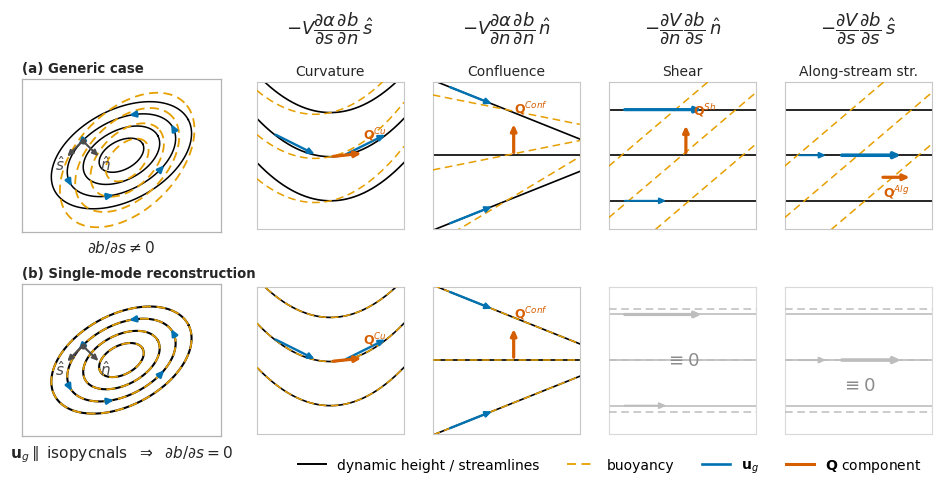

In [ ]:
# ==============================================================
# FIGURE 2: Q_fg natural-coordinate decomposition — schematic
# ==============================================================
TITLE = '.15'
C_PHI = '#000000'      # dynamic-height contours (= streamlines)
C_B   = '#E69F00'      # buoyancy contours
C_FL  = '#0072B2'      # geostrophic flow
C_Q   = '#D55E00'      # Q vector
C_SN  = '.30'          # natural coordinate vectors
OFF   = '#bdbdbd'

A_ELL, B_ELL, TILT = 30.0, 18.0, 28.0
SCALES = (0.42, 0.72, 1.02, 1.32)
B_TILT_OFF, B_X0, B_Y0, B_FA, B_FB = 17.0, 3.0, -2.5, 1.07, 1.10


def ell(t, a, b, tilt_deg, x0=0.0, y0=0.0, sc=1.0):
    th = np.radians(tilt_deg)
    xr, yr = sc * a * np.cos(t), sc * b * np.sin(t)
    return (xr * np.cos(th) - yr * np.sin(th) + x0,
            xr * np.sin(th) + yr * np.cos(th) + y0)


def ell_tan(t, a, b, tilt_deg, sc=1.0):
    th = np.radians(tilt_deg)
    dx_, dy_ = -sc * a * np.sin(t), sc * b * np.cos(t)
    tx = dx_ * np.cos(th) - dy_ * np.sin(th)
    ty = dx_ * np.sin(th) + dy_ * np.cos(th)
    m = np.hypot(tx, ty)
    return tx / m, ty / m


def arr(ax, x0, y0, x1, y1, color, lw=1.7, z=6, hw=0.13, hl=0.28, ls='-'):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1),
                                 arrowstyle=f'-|>,head_width={hw},head_length={hl}',
                                 mutation_scale=13, lw=lw, color=color,
                                 zorder=z, linestyle=ls))


fig = plt.figure(figsize=(9.6, 4.9))
gs = fig.add_gridspec(2, 5, width_ratios=[1.45, 1, 1, 1, 1],
                      hspace=0.34, wspace=0.18,
                      left=0.03, right=0.985, top=0.80, bottom=0.07)

t = np.linspace(0, 2 * np.pi, 500)


def draw_eddy(ax, coincide):
    for sc in SCALES:
        xs, ys = ell(t, A_ELL, B_ELL, TILT, sc=sc)
        ax.plot(xs, ys, color=C_PHI, lw=1.5 if coincide else 1.1, zorder=2)
    for sc in SCALES:
        if coincide:
            xs, ys = ell(t, A_ELL, B_ELL, TILT, sc=sc)
        else:
            xs, ys = ell(t, A_ELL * B_FA, B_ELL * B_FB, TILT + B_TILT_OFF,
                         x0=B_X0, y0=B_Y0, sc=sc)
        ax.plot(xs, ys, color=C_B, lw=1.3, ls=(0, (5, 3)), zorder=3)
    for tt in np.linspace(0, 2 * np.pi, 7)[:-1]:
        x0, y0 = ell(tt, A_ELL, B_ELL, TILT, sc=1.02)
        tx, ty = ell_tan(tt, A_ELL, B_ELL, TILT, sc=1.02)
        arr(ax, x0 - tx * 3.6, y0 - ty * 3.6, x0 + tx * 3.6, y0 + ty * 3.6,
            C_FL, lw=1.9)
    tp = np.radians(118.0)
    xp, yp = ell(tp, A_ELL, B_ELL, TILT, sc=1.02)
    tx, ty = ell_tan(tp, A_ELL, B_ELL, TILT, sc=1.02)
    nx, ny = -ty, tx
    Lv = 13.0
    arr(ax, xp, yp, xp + tx * Lv, yp + ty * Lv, C_SN, lw=1.5, hw=0.12, hl=0.26, z=8)
    arr(ax, xp, yp, xp + nx * Lv, yp + ny * Lv, C_SN, lw=1.5, hw=0.12, hl=0.26, z=8)
    ax.text(xp + tx * Lv * 1.30, yp + ty * Lv * 1.30, r'$\hat{s}$',
            color=C_SN, fontsize=11, ha='center', va='center', zorder=9)
    ax.text(xp + nx * Lv * 1.30, yp + ny * Lv * 1.30, r'$\hat{n}$',
            color=C_SN, fontsize=11, ha='center', va='center', zorder=9)
    ax.plot([xp], [yp], 'o', ms=3.4, color=C_SN, zorder=9)

    ax.set_xlim(-52, 52); ax.set_ylim(-40, 40)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color('.7'); s.set_linewidth(0.9)


ax_a = fig.add_subplot(gs[0, 0])
draw_eddy(ax_a, coincide=False)
ax_a.set_title('(a) Generic case', color=TITLE, fontsize=9.5, pad=5, fontweight='bold', loc='left')
ax_a.text(0.5, -0.045, r'$\partial b/\partial s \neq 0$',
          transform=ax_a.transAxes, ha='center', va='top',
          fontsize=11, color=TITLE)

ax_b = fig.add_subplot(gs[1, 0])
draw_eddy(ax_b, coincide=True)
ax_b.set_title('(b) Single-mode reconstruction', color=TITLE, fontsize=9.5, pad=5, fontweight='bold', loc='left')
ax_b.text(0.5, -0.045,
          r'$\mathbf{u}_g \parallel$ isopycnals  $\Rightarrow$  $\partial b/\partial s = 0$',
          transform=ax_b.transAxes, ha='center', va='top',
          fontsize=11, color=TITLE)


xx = np.linspace(-1, 1, 200)


def base(ax, active=True):
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color('.78' if active else '.85'); s.set_linewidth(0.8)


def curvature_sketch(ax, coincide):
    for off in (-0.62, -0.02, 0.58):
        ax.plot(xx, off + 0.52 * xx ** 2, color=C_PHI, lw=1.2, zorder=2)
    for off in (-0.62, -0.02, 0.58):
        if coincide:
            ax.plot(xx, off + 0.52 * xx ** 2, color=C_B, lw=1.1,
                    ls=(0, (5, 3)), zorder=3)
        else:
            ax.plot(xx, off + 0.52 * xx ** 2 + 0.22 * xx, color=C_B, lw=1.1,
                    ls=(0, (5, 3)), zorder=3)
    arr(ax, -0.78, -0.02 + 0.52 * 0.78 ** 2, -0.18, -0.02 + 0.52 * 0.18 ** 2,
        C_FL, lw=1.7)
    arr(ax, 0.18, -0.02 + 0.52 * 0.18 ** 2, 0.78, -0.02 + 0.52 * 0.78 ** 2,
        C_FL, lw=1.7)
    arr(ax, 0.0, -0.02, 0.46, 0.03, C_Q, lw=2.3, z=7)
    ax.text(0.60, 0.22, r'$\mathbf{Q}^{Cu}$', color=C_Q, fontsize=9,
            ha='center', zorder=8)


def confluence_sketch(ax, coincide):
    for off, sl in ((-0.62, 0.40), (0.0, 0.0), (0.62, -0.40)):
        ax.plot(xx, off + sl * xx, color=C_PHI, lw=1.2, zorder=2)
    for off, sl in ((-0.62, 0.40), (0.0, 0.0), (0.62, -0.40)):
        if coincide:
            ax.plot(xx, off + sl * xx, color=C_B, lw=1.1, ls=(0, (5, 3)), zorder=3)
        else:
            ax.plot(xx, off + sl * xx + 0.20 * xx, color=C_B, lw=1.1,
                    ls=(0, (5, 3)), zorder=3)
    arr(ax, -0.80, -0.62 + 0.40 * -0.80, -0.16, -0.62 + 0.40 * -0.16, C_FL, lw=1.7)
    arr(ax, -0.80, 0.62 - 0.40 * -0.80, -0.16, 0.62 - 0.40 * -0.16, C_FL, lw=1.7)
    arr(ax, 0.10, 0.0, 0.10, 0.46, C_Q, lw=2.3, z=7)
    ax.text(0.34, 0.58, r'$\mathbf{Q}^{Conf}$', color=C_Q, fontsize=9,
            ha='center', zorder=8)


def shear_sketch(ax, coincide):
    c_fl = OFF if coincide else C_FL
    c_ph = OFF if coincide else C_PHI
    c_b = OFF if coincide else C_B
    for off in (-0.62, 0.0, 0.62):
        ax.plot(xx, np.full_like(xx, off), color=c_ph, lw=1.2, zorder=2)
    for off in (-0.7, 0.0, 0.7):
        yb = 0.85 * xx + off if not coincide else np.full_like(xx, off)
        ax.plot(xx, yb, color=c_b, lw=1.1, ls=(0, (5, 3)), zorder=3)
    arr(ax, -0.82, 0.62, 0.30, 0.62, c_fl, lw=2.3)
    arr(ax, -0.82, -0.62, -0.18, -0.62, c_fl, lw=1.4)
    if not coincide:
        arr(ax, 0.05, 0.0, 0.05, 0.44, C_Q, lw=2.3, z=7)
        ax.text(0.30, 0.56, r'$\mathbf{Q}^{Sh}$', color=C_Q, fontsize=9,
                ha='center', zorder=8)
    else:
        ax.text(0.0, 0.0, r'$\equiv 0$', color='.55', fontsize=13,
                ha='center', va='center', zorder=8)


def along_sketch(ax, coincide):
    c_fl = OFF if coincide else C_FL
    c_ph = OFF if coincide else C_PHI
    c_b = OFF if coincide else C_B
    for off in (-0.62, 0.0, 0.62):
        ax.plot(xx, np.full_like(xx, off), color=c_ph, lw=1.2, zorder=2)
    for off in (-0.7, 0.0, 0.7):
        yb = 0.85 * xx + off if not coincide else np.full_like(xx, off)
        ax.plot(xx, yb, color=c_b, lw=1.1, ls=(0, (5, 3)), zorder=3)
    arr(ax, -0.84, 0.0, -0.40, 0.0, c_fl, lw=1.4)
    arr(ax, -0.26, 0.0, 0.62, 0.0, c_fl, lw=2.6)
    if not coincide:
        arr(ax, 0.30, -0.30, 0.74, -0.30, C_Q, lw=2.3, z=7)
        ax.text(0.52, -0.56, r'$\mathbf{Q}^{Alg}$', color=C_Q, fontsize=9,
                ha='center', zorder=8)
    else:
        ax.text(0.0, -0.34, r'$\equiv 0$', color='.55', fontsize=13,
                ha='center', va='center', zorder=8)


TERMS = [
    ('Curvature', r'$-V\dfrac{\partial\alpha}{\partial s}\dfrac{\partial b}{\partial n}\,\hat{s}$',
     curvature_sketch),
    ('Confluence', r'$-V\dfrac{\partial\alpha}{\partial n}\dfrac{\partial b}{\partial n}\,\hat{n}$',
     confluence_sketch),
    ('Shear', r'$-\dfrac{\partial V}{\partial n}\dfrac{\partial b}{\partial s}\,\hat{n}$',
     shear_sketch),
    ('Along-stream str.', r'$-\dfrac{\partial V}{\partial s}\dfrac{\partial b}{\partial s}\,\hat{s}$',
     along_sketch),
]

for col, (name, expr, drawer) in enumerate(TERMS, start=1):
    axt = fig.add_subplot(gs[0, col])
    base(axt, active=True)
    drawer(axt, coincide=False)
    axt.set_title(name, color=TITLE, fontsize=10, pad=5)
    axt.text(0.5, 1.25, expr, transform=axt.transAxes, ha='center', va='bottom',
             fontsize=13, color=TITLE)

    axb2 = fig.add_subplot(gs[1, col])
    active = col <= 2
    base(axb2, active=active)
    drawer(axb2, coincide=True)

handles = [Line2D([], [], color=C_PHI, lw=1.4, label='dynamic height / streamlines'),
           Line2D([], [], color=C_B, lw=1.3, ls=(0, (5, 3)), label='buoyancy'),
           Line2D([], [], color=C_FL, lw=1.9, label=r'$\mathbf{u}_g$'),
           Line2D([], [], color=C_Q, lw=2.2, label=r'$\mathbf{Q}$ component')]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
           fontsize=10, bbox_to_anchor=(0.65, -0.035))

# fig.savefig(f"{DIR_FIGURES}/figure2.png", bbox_inches='tight', dpi=200)
plt.show()

### Figure 3 — sigma0 / Ro / w_fg at 100, 300, 500 m

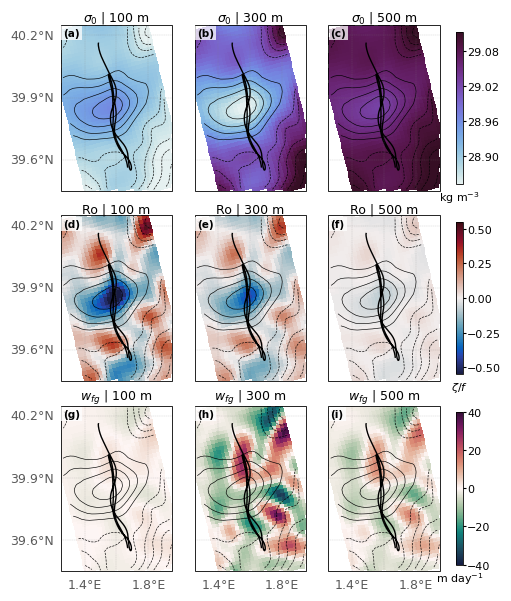

In [ ]:
# ==============================================================
# FIGURE 3: sigma0 / Ro / w_fg at 100, 300, 500 m
# ==============================================================
z_levels_fig3 = Z_LEVELS_FIG3
panel_labels = list("abcdefghi")
extent = [LONMIN, LONMAX, LATMIN, LATMAX]

SIG_maps, RO_maps, W_maps = [], [], []
for zt in z_levels_fig3:
    iz_sig = np.argmin(np.abs(p_valid - zt))
    SIG_maps.append(np.where(swot_mask, sigma0_recon[1:-1, 1:-1, iz_sig], np.nan))

    Ro = rossby_filtered(u, v, dx, dy, depth, zt, lat_i)
    RO_maps.append(np.where(swot_mask, Ro, np.nan))

    iz_w = np.argmin(np.abs(depth[1:-1] - zt))
    W_maps.append(np.where(swot_mask, w_fg[iz_w] * 86400.0, np.nan))

sig_vmin, sig_vmax = np.nanpercentile(np.array(SIG_maps), [2, 98])
ro_vmin, ro_vmax = -0.55, 0.55
w_vmin, w_vmax = -40, 40

plt.rcParams.update({
    'font.size': 9, 'axes.titlesize': 9, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'font.family': 'sans-serif', 'mathtext.fontset': 'dejavusans',
    'axes.linewidth': 0.6, 'savefig.dpi': 350,
})

fig, axs = plt.subplots(3, 3, figsize=(4.6, 6.5),
                        subplot_kw={'projection': ccrs.Mercator()})
pm_sig = pm_ro = pm_w = None

for r in range(3):
    for c, zt in enumerate(z_levels_fig3):
        ax = axs[r, c]
        if r == 0:
            pm = ax.pcolormesh(lon_i, lat_i, SIG_maps[c], cmap=cmocean.cm.dense,
                               vmin=sig_vmin, vmax=sig_vmax, shading='auto',
                               rasterized=True, transform=ccrs.PlateCarree())
            pm_sig = pm_sig or pm; title_core = r"$\sigma_0$"
        elif r == 1:
            pm = ax.pcolormesh(lon_i, lat_i, RO_maps[c], cmap=cmocean.cm.balance,
                               vmin=ro_vmin, vmax=ro_vmax, shading='auto',
                               rasterized=True, transform=ccrs.PlateCarree())
            pm_ro = pm_ro or pm; title_core = "Ro"
        else:
            pm = ax.pcolormesh(lon_i, lat_i, W_maps[c], cmap=cmocean.cm.curl,
                               vmin=w_vmin, vmax=w_vmax, shading='auto',
                               rasterized=True, transform=ccrs.PlateCarree())
            pm_w = pm_w or pm; title_core = r"$w_{fg}$"

        levels = np.arange(-4, 4.1, 0.5)
        levels = levels[np.abs(levels) > 1e-6]
        ax.contour(lon_i, lat_i, ssh_i, levels=levels,
                   colors='k', linewidths=0.45, transform=ccrs.PlateCarree())

        ax.plot(Lon09, Lat09, 'k-', lw=1.0, transform=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.55)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.text(0.02, 0.98, f"({panel_labels[r*3+c]})", transform=ax.transAxes,
                va='top', ha='left', fontsize=7.5, fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.5))
        ax.set_title(rf"{title_core} | {zt} m", pad=2)

        gl = ax.gridlines(draw_labels=True, linewidth=0.25, linestyle='--',
                          color='gray', alpha=0.5)
        gl.top_labels = gl.right_labels = False
        gl.left_labels = (c == 0); gl.bottom_labels = (r == 2)
        gl.xlocator = mticker.MaxNLocator(4); gl.ylocator = mticker.MaxNLocator(3)
        gl.xlabel_style = gl.ylabel_style = {'size': 9, 'color': '0.35'}

fig.subplots_adjust(left=0.06, right=0.93, top=0.95, bottom=0.11,
                    wspace=0.01, hspace=0.15)

def add_row_cbar(row_idx, mappable, label, ticks=None):
    pos = axs[row_idx, -1].get_position()
    cax = fig.add_axes([pos.x1 + 0.035, pos.y0 + 0.01, 0.015, pos.height - 0.02])
    cb = fig.colorbar(mappable, cax=cax, orientation='vertical')
    cb.ax.tick_params(labelsize=8, length=2, pad=1)
    if ticks is not None:
        cb.set_ticks(ticks)
    else:
        cb.locator = mticker.MaxNLocator(5); cb.update_ticks()
    cax.set_xlabel(label, fontsize=8, labelpad=4)
    cax.xaxis.set_label_position('bottom')

add_row_cbar(0, pm_sig, r'kg m$^{-3}$')
add_row_cbar(1, pm_ro,  r'$\zeta/f$', ticks=[-0.5, -0.25, 0.0, 0.25, 0.5])
add_row_cbar(2, pm_w,   r'm day$^{-1}$', ticks=[-40, -20, 0, 20, 40])

# plt.savefig(f"{DIR_FIGURES}/figure3.png",
#             dpi=350, bbox_inches='tight')
plt.show()

### Figure 4 — CTD validation (T6, 26 Apr 2023)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31424\1464281063.py:24: RuntimeWarning: Mean of empty slice
  ctd_mean_T6 = np.nanmean(sigma0_L1T6, axis=0)   # (nz,)


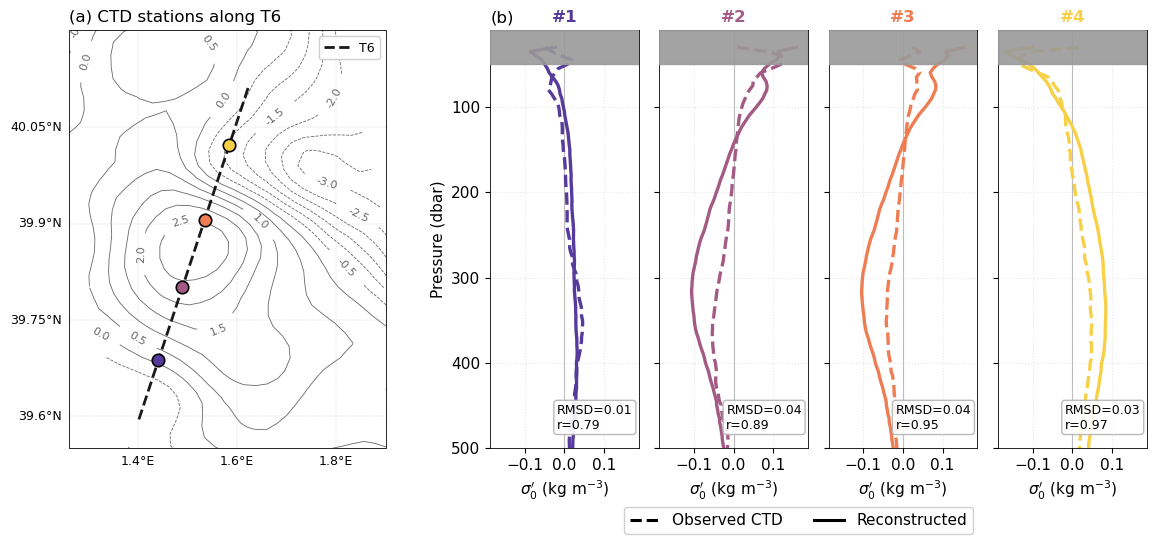

In [ ]:
# ==============================================================
# FIGURE 4 — CTD VALIDATION T6: (a) map of stations | (b) 4 profiles (anomaly)
# ==============================================================
lon2d, lat2d = rec_T6['lon_swot'], rec_T6['lat_swot']
adt_anom_T6 = rec_T6['adt_anom']

cmap_leg1 = cmocean.cm.thermal
colors_L1T6 = cmap_leg1(np.linspace(0.25, 0.90, n_T6))

order = np.argsort(lat_L1T6)
lon_o, lat_o = lon_L1T6[order], lat_L1T6[order]
ext = 0.10
dlon, dlat = lon_o[-1] - lon_o[0], lat_o[-1] - lat_o[0]
norm = np.hypot(dlon, dlat)
elon, elat = ext * dlon / norm, ext * dlat / norm
lonA, latA = lon_o[0] - elon, lat_o[0] - elat
lonB, latB = lon_o[-1] + elon, lat_o[-1] + elat

p_arr = np.asarray(p_valid)
mmask = (p_arr >= 30) & (p_arr <= 700)
p_plot = p_arr[mmask]

# reference profile shared by both curves: mean of the 4 T6 CTD casts
ctd_mean_T6 = np.nanmean(sigma0_L1T6, axis=0)   # (nz,)

# ---- figure ----
fig = plt.figure(figsize=(12, 5.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.9], wspace=0.18,
                      left=0.06, right=0.97, top=0.90, bottom=0.14)

# --- (a) map ---
ax_map = fig.add_subplot(gs[0], projection=ccrs.Mercator())
c_map = ax_map.contour(lon2d, lat2d, adt_anom_T6 * 100,
                       levels=np.arange(-3, 3.1, 0.5), colors='k',
                       linewidths=0.6, alpha=0.6, transform=ccrs.PlateCarree())
ax_map.clabel(c_map, inline=True, fontsize=8, fmt='%.1f')
ax_map.plot([lonA, lonB], [latA, latB], 'k--', lw=2.0, alpha=0.9,
            transform=ccrs.PlateCarree(), label='T6')
for j in range(n_T6):
    ax_map.scatter(lon_L1T6[j], lat_L1T6[j], s=80, color=colors_L1T6[j],
                   edgecolor='k', lw=1.2, zorder=5, transform=ccrs.PlateCarree())
ax_map.legend(loc='upper right', fontsize=9, framealpha=0.92)
ax_map.coastlines(linewidth=0.8)
ax_map.set_extent([1.26, 1.9, 39.55, 40.2], crs=ccrs.PlateCarree())
gl = ax_map.gridlines(draw_labels=True, linewidth=0.3, linestyle='--', color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False
gl.xlocator = mticker.MaxNLocator(4); gl.ylocator = mticker.MaxNLocator(5)
ax_map.set_title('(a) CTD stations along T6', loc='left', fontsize=12, pad=6)

# --- (b) 4 profiles (anomaly wrt the mean of the 4 CTD, same reference for both curves) ---
mstat = (p_arr >= 50) & (p_arr <= 500)
all_vals = np.concatenate(
    [sigma0_L1T6[j][mmask]  - ctd_mean_T6[mmask] for j in range(n_T6)] +
    [sig_rec_L1T6[j][mmask] - ctd_mean_T6[mmask] for j in range(n_T6)]
)
xlim = np.nanmax(np.abs(all_vals)) * 1.1

gs_prof = gs[1].subgridspec(1, n_T6, wspace=0.14)
for j in range(n_T6):
    ax = fig.add_subplot(gs_prof[0, j])
    o_anom = sigma0_L1T6[j][mmask]  - ctd_mean_T6[mmask]
    r_anom = sig_rec_L1T6[j][mmask] - ctd_mean_T6[mmask]

    o_stat = sigma0_L1T6[j][mstat]  - ctd_mean_T6[mstat]
    r_stat = sig_rec_L1T6[j][mstat] - ctd_mean_T6[mstat]
    mm = np.isfinite(o_stat) & np.isfinite(r_stat)
    rmsd = np.sqrt(np.mean((o_stat[mm] - r_stat[mm])**2))
    corr = np.corrcoef(o_stat[mm], r_stat[mm])[0, 1]

    ax.axhspan(10, 50, color='0.6', alpha=0.9, zorder=5)
    ax.axvline(0, color='0.75', lw=0.8, zorder=0)
    ax.plot(o_anom, p_plot, '--', color=colors_L1T6[j], lw=2.4)
    ax.plot(r_anom, p_plot, '-',  color=colors_L1T6[j], lw=2.4)
    ax.set_xlim(-xlim, xlim)
    ax.set_ylim(500, 10)
    ax.set_title(f"#{j+1}", fontsize=12, color=colors_L1T6[j], fontweight='bold')
    ax.grid(True, alpha=0.3, ls=':')
    ax.text(0.45, 0.04, f"RMSD={rmsd:.2f}\nr={corr:.2f}", transform=ax.transAxes,
             fontsize=9, ha='left', va='bottom', zorder=11,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='0.7', boxstyle='round,pad=0.25'))
    ax.set_xlabel(r"$\sigma_0'$ (kg m$^{-3}$)", fontsize=11)
    ax.tick_params(axis='x', labelsize=11)

    if j == 0:
        ax.set_ylabel('Pressure (dbar)', fontsize=11)
        ax.set_title('(b)', loc='left', fontsize=12, pad=6)
        ax.tick_params(axis='y', labelsize=11)
    else:
        ax.set_yticklabels([])

fig.legend(handles=[Line2D([0],[0], color='k', lw=2.2, ls='--', label='Observed CTD'),
                    Line2D([0],[0], color='k', lw=2.2, ls='-', label='Reconstructed')],
           loc='lower center', ncol=2, fontsize=11, framealpha=0.92, bbox_to_anchor=(0.68, -0.03))

# plt.savefig(f"{DIR_FIGURES}/figure4.png", dpi=350, bbox_inches='tight')
plt.show()

### Figure 5 — ADCP velocity validation (T6, 26 Apr 2023) + isopycnal-depth map

Butterworth 8 km: RMSE=0.077  Corr=0.96


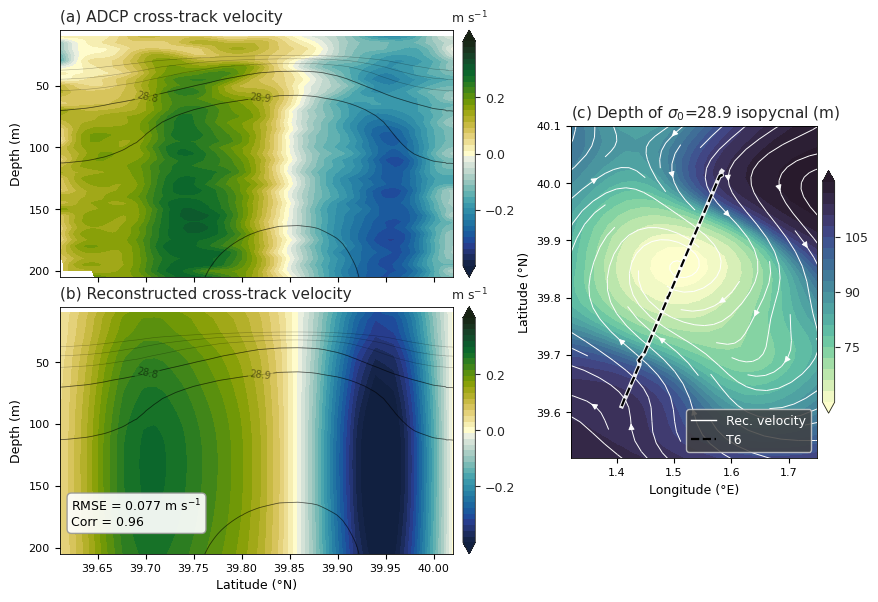

In [ ]:
# ============================================================
# FIGURE 5 — VELOCITY VALIDATION T6
# ADCP: interpolated to a regular DISTANCE axis (0.25 km) -> Butterworth
#       (filtfilt) -> cross-track. Reconstruction: bilinear projection
#       (triangulation built once -> fast).
# ============================================================
SIG_TARGET = 28.9
V_VMAX = 0.4
N_LEVELS = 40
CUTOFF_KM = 8.0
DX_REG_KM = 0.25
BUTTER_ORDER = 4
ZOOM_LON = (1.32, 1.75)
ZOOM_LAT = (39.52, 40.1)
ISO_SEC = np.arange(28.5, 29.21, 0.1)
ISO_SEC_KEY = np.array([28.8, 28.9, 29.0])
ISO_SEC_LABEL_LAT = {28.8: 39.70, 28.9: 39.82, 29.0: 39.95}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2*np.arctan2(np.sqrt(a), np.sqrt(1-a))

def low_pass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    b_, a_ = butter(order, cutoff/nyq, btype='low', analog=False)
    return filtfilt(b_, a_, data)

# ---- ADCP data ----
lat_adcp = np.asarray(adcp_T6['lat'], float)
lon_adcp = np.asarray(adcp_T6['lon'], float)
adcp_z   = np.asarray(adcp_T6['depth'], float)
uA = np.asarray(adcp_T6['u'], float); vA = np.asarray(adcp_T6['v'], float)
if uA.shape[0] != len(lat_adcp) and uA.shape[1] == len(lat_adcp):
    uA, vA = uA.T, vA.T
ndep = uA.shape[1]

d0 = np.array([haversine(lat_adcp[0], lon_adcp[0], la, lo)
               for la, lo in zip(lat_adcp, lon_adcp)])
order5 = np.argsort(d0); d0 = d0[order5]
uA = uA[order5, :]; vA = vA[order5, :]; lat_s = lat_adcp[order5]; lon_s = lon_adcp[order5]
reg_d = np.arange(0, d0[-1], DX_REG_KM)
fs = 1.0 / DX_REG_KM
cutoff = 1.0 / CUTOFF_KM
lat_reg = interp1d(d0, lat_s, kind='linear')(reg_d)
lon_reg = interp1d(d0, lon_s, kind='linear')(reg_d)

u_filt_reg = np.full((reg_d.size, ndep), np.nan)
v_filt_reg = np.full((reg_d.size, ndep), np.nan)
for k in range(ndep):
    ug = np.isfinite(uA[:, k]) & np.isfinite(vA[:, k])
    if ug.sum() < BUTTER_ORDER*3 + 1: continue
    ui = interp1d(d0[ug], uA[ug, k], kind='linear', bounds_error=False)(reg_d)
    vi = interp1d(d0[ug], vA[ug, k], kind='linear', bounds_error=False)(reg_d)
    valid = np.isfinite(ui) & np.isfinite(vi)
    if valid.sum() < BUTTER_ORDER*3 + 1: continue
    uf = np.full_like(ui, np.nan); vf = np.full_like(vi, np.nan)
    uf[valid] = low_pass_filter(ui[valid], cutoff, fs, BUTTER_ORDER)
    vf[valid] = low_pass_filter(vi[valid], cutoff, fs, BUTTER_ORDER)
    u_filt_reg[:, k] = uf; v_filt_reg[:, k] = vf

dlon = lon_s[-1] - lon_s[0]; dlat = lat_s[-1] - lat_s[0]
mean_lat = math.radians((lat_s[0] + lat_s[-1]) / 2.0)
angle = np.rad2deg(np.arctan2(dlat, dlon*math.cos(mean_lat)))
rot = np.exp(1j*(-angle)*np.pi/180)
ct_obs_reg = ((u_filt_reg + 1j*v_filt_reg) * rot).imag

# ---- reconstruction: bilinear projection (triangulation built once) ----
lon2d_v = np.asarray(rec_T6['lon_swot'], float); lat2d_v = np.asarray(rec_T6['lat_swot'], float)
u3d = rec_T6['u_geo']; v3d = rec_T6['v_geo']; sig3d = rec_T6['sigma0_recon']
depth_v = np.asarray(rec_T6['depth'], float); ny_v, nx_v, nz_v = sig3d.shape

base_valid = np.isfinite(lon2d_v.ravel()) & np.isfinite(lat2d_v.ravel())
pts_all = np.column_stack((lon2d_v.ravel()[base_valid], lat2d_v.ravel()[base_valid]))
tri = Delaunay(pts_all)
tgt = np.column_stack((lon_reg, lat_reg))

def interp_column_field(field3d):
    out = np.full((tgt.shape[0], nz_v), np.nan)
    for k in range(nz_v):
        vals = field3d[:, :, k].ravel()[base_valid]
        good = np.isfinite(vals)
        if good.sum() < 4:
            continue
        if good.all():
            interp = LinearNDInterpolator(tri, vals)
        else:
            interp = LinearNDInterpolator(pts_all[good], vals[good])
        out[:, k] = interp(tgt)
    return out

u_col = interp_column_field(u3d)
v_col = interp_column_field(v3d)
sig_col = interp_column_field(sig3d)

Ug = np.full((tgt.shape[0], adcp_z.size), np.nan)
Vg = np.full((tgt.shape[0], adcp_z.size), np.nan)
for i in range(tgt.shape[0]):
    g = np.isfinite(u_col[i, :])
    if g.sum() >= 2:
        Ug[i, :] = np.interp(adcp_z, depth_v[g], u_col[i, g], left=np.nan, right=np.nan)
        Vg[i, :] = np.interp(adcp_z, depth_v[g], v_col[i, g], left=np.nan, right=np.nan)
ct_rec_reg = ((Ug + 1j*Vg) * rot).imag

sig_along = sig_col.T
zmask = depth_v <= (np.nanmax(adcp_z) + 10)
sig_top = sig_along[zmask, :]; depth_top = depth_v[zmask]

rmse_ct_f, corr_ct_f = adcp_recon_metrics(ct_obs_reg, ct_rec_reg, adcp_z)
print(f"Butterworth 8 km: RMSE={rmse_ct_f:.3f}  Corr={corr_ct_f:.2f}")

xax = lat_reg

def clean_cbar(cb, unit=None):
    cb.locator = MaxNLocator(nbins=5, prune='both'); cb.update_ticks()
    cb.ax.tick_params(labelsize=9, colors='.15')
    cb.outline.set_edgecolor('.15'); cb.set_label('')
    if unit is not None:
        cb.ax.set_title(unit, fontsize=9, pad=5, color='.15')

def set_title(ax, t):
    ax.set_title(t, loc='left', fontsize=11, fontweight='medium', color='.15', pad=6)

h_iso = np.full((ny_v, nx_v), np.nan)
for j in range(ny_v):
    for i in range(nx_v):
        col = sig3d[j,i,:]; g = np.isfinite(col)
        if g.sum() < 5: continue
        c = col[g]; z = depth_v[g]
        k = np.where(np.diff(np.sign(c - SIG_TARGET)))[0]
        if len(k):
            kk=k[0]; f=(SIG_TARGET-c[kk])/(c[kk+1]-c[kk]); h_iso[j,i]=z[kk]+f*(z[kk+1]-z[kk])
kzr = np.argmin(np.abs(depth_v - 100.0))

def overlay_iso_sec(ax):
    ax.contour(xax, depth_top, sig_top, levels=ISO_SEC, colors='k', linewidths=0.4, alpha=0.3)
    cs = ax.contour(xax, depth_top, sig_top, levels=ISO_SEC_KEY, colors='k', linewidths=0.6, alpha=0.45)
    man=[]
    for lev in ISO_SEC_KEY:
        jj=np.argmin(np.abs(xax-ISO_SEC_LABEL_LAT[lev])); col=sig_top[:,jj]
        k=np.where(np.diff(np.sign(col-lev)))[0]
        if len(k): man.append((xax[jj], depth_top[k[0]]))
    if man: ax.clabel(cs, fmt='%.1f', fontsize=7, manual=man, inline_spacing=2)

# ---- figure ----
fig = plt.figure(figsize=(10, 6.8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.8, 1], height_ratios=[1,1], wspace=0.10, hspace=0.12)
ax_obs = fig.add_subplot(gs[0,0]); ax_rec = fig.add_subplot(gs[1,0], sharex=ax_obs)
ax_map = fig.add_subplot(gs[:,1])

cf = ax_obs.contourf(xax, adcp_z, ct_obs_reg.T, levels=np.linspace(-V_VMAX,V_VMAX,N_LEVELS),
                     cmap=cmocean.cm.delta, extend='both')
cb = plt.colorbar(cf, ax=ax_obs, pad=0.02); clean_cbar(cb, r'm s$^{-1}$')
overlay_iso_sec(ax_obs)
ax_obs.set_ylim(np.nanmax(adcp_z),5); ax_obs.yaxis.set_major_locator(MultipleLocator(50))
ax_obs.set_ylabel('Depth (m)'); set_title(ax_obs, '(a) ADCP cross-track velocity')
plt.setp(ax_obs.get_xticklabels(), visible=False)

cf = ax_rec.contourf(xax, adcp_z, ct_rec_reg.T, levels=np.linspace(-V_VMAX,V_VMAX,N_LEVELS),
                     cmap=cmocean.cm.delta, extend='both')
cb = plt.colorbar(cf, ax=ax_rec, pad=0.02); clean_cbar(cb, r'm s$^{-1}$')
overlay_iso_sec(ax_rec)
ax_rec.set_ylim(np.nanmax(adcp_z),5); ax_rec.yaxis.set_major_locator(MultipleLocator(50))
ax_rec.set_ylabel('Depth (m)'); ax_rec.set_xlabel('Latitude (°N)')
set_title(ax_rec, '(b) Reconstructed cross-track velocity')
ax_rec.text(0.03, 0.10, f"RMSE = {rmse_ct_f:.3f} m s$^{{-1}}$\nCorr = {corr_ct_f:.2f}",
            transform=ax_rec.transAxes, fontsize=9, va='bottom', ha='left',
            bbox=dict(facecolor='white', alpha=0.92, edgecolor='0.6', boxstyle='round,pad=0.35'))

cf = ax_map.contourf(lon2d_v, lat2d_v, h_iso, levels=21, cmap=cmocean.cm.deep, extend='both')
cb = plt.colorbar(cf, ax=ax_map, pad=0.02, fraction=0.046); clean_cbar(cb, unit=None)
lon_r = np.linspace(np.nanmin(lon2d_v), np.nanmax(lon2d_v), 70)
lat_r = np.linspace(np.nanmin(lat2d_v), np.nanmax(lat2d_v), 70)
LON, LAT = np.meshgrid(lon_r, lat_r)
pts = np.c_[lon2d_v.ravel(), lat2d_v.ravel()]
mm = np.isfinite(u3d[:,:,kzr].ravel()) & np.isfinite(v3d[:,:,kzr].ravel())
U = griddata(pts[mm], u3d[:,:,kzr].ravel()[mm], (LON,LAT), method='linear')
V = griddata(pts[mm], v3d[:,:,kzr].ravel()[mm], (LON,LAT), method='linear')
ax_map.streamplot(lon_r, lat_r, U, V, color='w', density=1.2, linewidth=0.7, arrowsize=0.9)
ax_map.plot(lon_reg, lat_reg, 'w-', lw=3.2, zorder=5, alpha=0.9)
ax_map.plot(lon_reg, lat_reg, 'k--', lw=1.6, zorder=6)
legend_handles = [
    Line2D([0], [0], color='w', lw=1.0, label='Rec. velocity'),
    Line2D([0], [0], color='k', lw=1.6, ls='--', label='T6'),
]
leg = ax_map.legend(handles=legend_handles, loc='lower right', fontsize=9)
leg.get_frame().set_facecolor('0.25'); leg.get_frame().set_alpha(0.85)
for t_ in leg.get_texts(): t_.set_color('white')
ax_map.set_xlim(*ZOOM_LON); ax_map.set_ylim(*ZOOM_LAT); ax_map.set_aspect('equal', adjustable='box')
ax_map.set_xlabel('Longitude (°E)'); ax_map.set_ylabel('Latitude (°N)')
set_title(ax_map, f'(c) Depth of $\\sigma_0$={SIG_TARGET} isopycnal (m)')

# plt.savefig(f"{DIR_FIGURES}/figure5.png", dpi=350, bbox_inches='tight')
plt.show()

### Figure 6 — Tracer anomalies (chl', O2', spice') and w_QG, remapped to depth

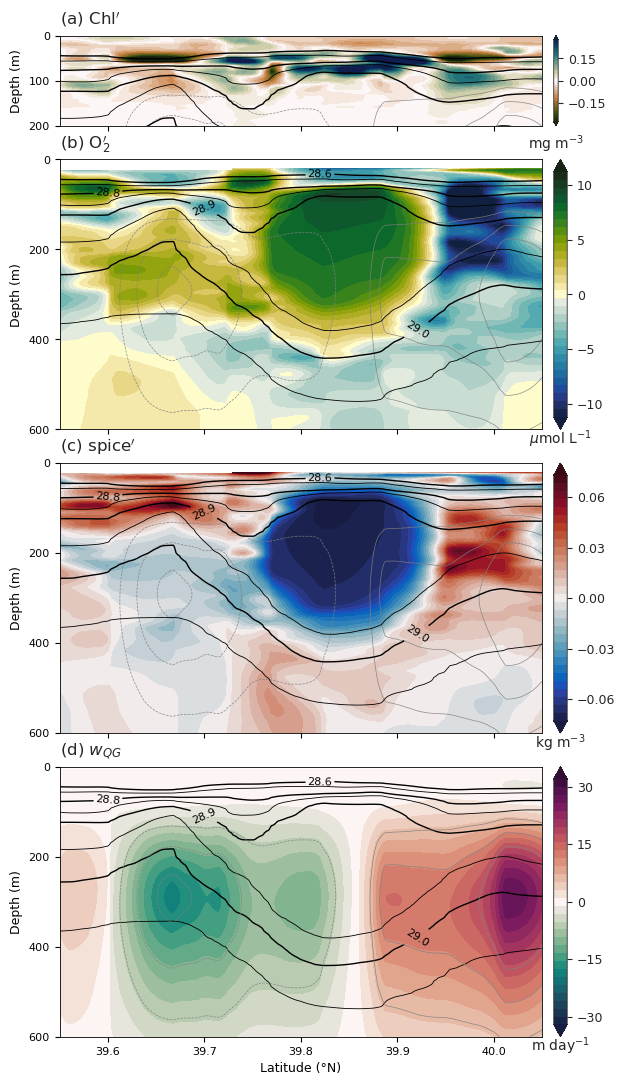

In [ ]:
# ============================================================
# FIGURE 6 — Chl', O2', spice', w_QG remapped from isopycnal to depth coords
# Filtering: horizontal median (replaces outlier profiles, does NOT average)
#            + light Gaussian (smooths shapes)
#            + row-wise PCHIP for display only (kills contourf zig-zag,
#              no overshoot, does not touch the values at real profiles)
# ============================================================
Z_MAX, Z_CHL_MAX = 600.0, 200.0
NZ        = 160
N_LEVELS  = 32
LAT_MIN, LAT_MAX = 39.55, 40.05
W_VMAX    = 32
UPS       = 6            # horizontal upsampling, display only

F_O2   = (3, 1.2, 0.8)   # (med_lat, sig_lat, sig_z)
F_SP   = (3, 1.2, 0.8)
F_CHL  = (1, 1.0, 0.8)
F_W    = (1, 0.8, 0.8)
F_SIG  = (1, 1.5, 0.5)

ISO_KEY  = np.array([28.6, 28.8, 28.9, 29.0])
ISO_REST = np.array([28.7, 28.85, 28.95, 29.05])
ISO_LABEL_LAT = {28.6: 39.82, 28.8: 39.60, 28.9: 39.70, 29.0: 39.92}
TITLE_COLOR, TITLE_SIZE, TITLE_WEIGHT = '.15', 12, 'light'

depth_reg = np.linspace(5.0, Z_MAX, NZ)
nprof6 = O2_anom_iso.shape[1]
zg6    = np.asarray(depth_glider, float)
SIG6   = np.asarray(sigma0_glider_sel, float)
LATG6  = np.asarray(latg, float)

def iso_to_depth(field_iso):
    out = np.full((NZ, nprof6), np.nan)
    for j in range(nprof6):
        z_col, f_col = z_iso[:, j], field_iso[:, j]
        m = np.isfinite(z_col) & np.isfinite(f_col)
        if m.sum() < 5:
            continue
        zz, ff = z_col[m], f_col[m]
        o = np.argsort(zz); zz, ff = zz[o], ff[o]
        zz_u, iu = np.unique(zz, return_index=True)
        out[:, j] = np.interp(depth_reg, zz_u, ff[iu], left=np.nan, right=np.nan)
    return out

_xi = np.arange(nprof6, dtype=float)
_xf = np.linspace(0.0, nprof6 - 1.0, (nprof6 - 1) * UPS + 1)
lat_p = np.interp(_xf, _xi, LATG6)

def _fill_rows(A):
    B = A.copy(); idx = np.arange(A.shape[1])
    for i in range(A.shape[0]):
        m = np.isfinite(B[i])
        if 0 < m.sum() < A.shape[1]:
            B[i] = np.interp(idx, idx[m], B[i][m])
    return B

def prettify(A, med_lat=3, sig_lat=1.2, sig_z=0.8):
    """1) horizontal median  2) light Gaussian  3) horizontal PCHIP for display."""
    A = np.asarray(A, float)
    if med_lat > 1:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            A = generic_filter(A, np.nanmedian, size=(1, med_lat), mode='nearest')
    M   = np.isfinite(A).astype(float)
    num = gaussian_filter(np.where(np.isfinite(A), A, 0.0), sigma=(sig_z, sig_lat), mode='nearest')
    den = gaussian_filter(M, sigma=(sig_z, sig_lat), mode='nearest')
    B   = np.full_like(num, np.nan)
    np.divide(num, den, out=B, where=den > 0.3)
    out = np.full((B.shape[0], _xf.size), np.nan)
    for i in range(B.shape[0]):
        m = np.isfinite(B[i])
        if m.sum() < 4:
            continue
        xv = _xi[m]
        out[i] = PchipInterpolator(xv, B[i][m])(_xf)
        out[i][(_xf < xv[0]) | (_xf > xv[-1])] = np.nan
    return out

O2_raw = iso_to_depth(O2_anom_iso)
SP_raw = iso_to_depth(spice_anom_iso)

CH = np.asarray(chl_sel, float)
chl_z_raw = np.full((NZ, nprof6), np.nan)
for j in range(nprof6):
    m = np.isfinite(zg6) & np.isfinite(CH[j, :])
    if m.sum() < 5:
        continue
    zz, vv = zg6[m], CH[j, :][m]; o = np.argsort(zz)
    chl_z_raw[:, j] = np.interp(depth_reg, zz[o], vv[o], left=np.nan, right=np.nan)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    CH_raw = chl_z_raw - np.nanmean(chl_z_raw, axis=1)[:, None]

w_raw = np.full((NZ, nprof6), np.nan)
for j in range(nprof6):
    w_raw[:, j] = np.interp(depth_reg, depth_grid, w_glider_mday[:, j], left=np.nan, right=np.nan)

sig_raw = np.full((NZ, nprof6), np.nan)
for j in range(nprof6):
    m = np.isfinite(SIG6[j, :]) & np.isfinite(zg6)
    if m.sum() < 5:
        continue
    zz, ss = zg6[m], SIG6[j, :][m]; o = np.argsort(zz)
    sig_raw[:, j] = np.interp(depth_reg, zz[o], ss[o], left=np.nan, right=np.nan)
sig_raw = _fill_rows(sig_raw)

O2_p = prettify(O2_raw,  *F_O2)
SP_p = prettify(SP_raw,  *F_SP)
CH_p = prettify(CH_raw,  *F_CHL); CH_p[depth_reg > Z_CHL_MAX, :] = np.nan
W_p  = prettify(w_raw,   *F_W)
SG_p = prettify(sig_raw, *F_SIG)

def overlay_isopycnals(ax, labels=True):
    ax.contour(lat_p, depth_reg, SG_p, levels=ISO_REST, colors='k', linewidths=0.6)
    cs = ax.contour(lat_p, depth_reg, SG_p, levels=ISO_KEY, colors='k', linewidths=1.0)
    if labels:
        manual = []
        for lev in ISO_KEY:
            jj = np.argmin(np.abs(lat_p - ISO_LABEL_LAT.get(lev, LAT_MIN + 0.1)))
            k = np.where(np.diff(np.sign(SG_p[:, jj] - lev)))[0]
            if len(k):
                manual.append((lat_p[jj], depth_reg[k[0]]))
        if manual:
            ax.clabel(cs, fmt='%.1f', fontsize=8, manual=manual, inline_spacing=2)

def overlay_w_white(ax):
    wa = np.nanpercentile(np.abs(W_p), 95)
    lv = np.arange(wa / 3, wa + wa / 3, wa / 3)
    ax.contour(lat_p, depth_reg, W_p, levels=lv, colors='gray',
               linewidths=0.5, linestyles='solid', alpha=0.9)
    ax.contour(lat_p, depth_reg, W_p, levels=-lv[::-1], colors='gray',
               linewidths=0.5, linestyles='dashed', alpha=0.9)

def clean_cbar6(cb, unit_label):
    cb.locator = MaxNLocator(nbins=5, prune='both'); cb.update_ticks()
    cb.ax.tick_params(labelsize=9, colors=TITLE_COLOR)
    cb.outline.set_edgecolor(TITLE_COLOR)
    cb.set_label('')
    cb.ax.set_xlabel(unit_label, fontsize=10, labelpad=8, color=TITLE_COLOR)
    cb.ax.xaxis.set_label_position('bottom')

def set_title6(ax, text):
    ax.set_title(text, loc='left', fontsize=TITLE_SIZE,
                 fontweight=TITLE_WEIGHT, color=TITLE_COLOR, pad=8)

def set_ydepth(ax, zmax, step=200):
    ax.set_ylim(zmax, 0); ax.yaxis.set_major_locator(MultipleLocator(step))

# ---------- figure ----------
fig = plt.figure(figsize=(7.5, 13.0))
gs6  = gridspec.GridSpec(4, 1, height_ratios=[1.0, 3.0, 3.0, 3.0], hspace=0.15)
ax_chl = fig.add_subplot(gs6[0])
ax_o2  = fig.add_subplot(gs6[1], sharex=ax_chl)
ax_sp  = fig.add_subplot(gs6[2], sharex=ax_chl)
ax_w   = fig.add_subplot(gs6[3], sharex=ax_chl)

v  = np.nanpercentile(np.abs(CH_p), 97)
cf = ax_chl.contourf(lat_p, depth_reg, CH_p, levels=np.linspace(-v, v, N_LEVELS),
                     cmap=cmocean.cm.tarn, extend='both')
clean_cbar6(plt.colorbar(cf, ax=ax_chl, pad=0.02), r"mg m$^{-3}$")
overlay_w_white(ax_chl); overlay_isopycnals(ax_chl, labels=False)
set_ydepth(ax_chl, Z_CHL_MAX, step=100); ax_chl.set_xlim(LAT_MIN, LAT_MAX)
ax_chl.set_ylabel('Depth (m)'); set_title6(ax_chl, r"(a) Chl$'$")
plt.setp(ax_chl.get_xticklabels(), visible=False)

v  = np.nanpercentile(np.abs(O2_p), 99)
cf = ax_o2.contourf(lat_p, depth_reg, O2_p, levels=np.linspace(-v, v, N_LEVELS),
                    cmap=cmocean.cm.delta, extend='both')
clean_cbar6(plt.colorbar(cf, ax=ax_o2, pad=0.02), r"$\mu$mol L$^{-1}$")
overlay_w_white(ax_o2); overlay_isopycnals(ax_o2)
set_ydepth(ax_o2, Z_MAX); ax_o2.set_ylabel('Depth (m)')
set_title6(ax_o2, r"(b) O$_2'$")
plt.setp(ax_o2.get_xticklabels(), visible=False)

v  = np.nanpercentile(np.abs(SP_p), 99)
cf = ax_sp.contourf(lat_p, depth_reg, SP_p, levels=np.linspace(-v, v, N_LEVELS),
                    cmap=cmocean.cm.balance, extend='both')
clean_cbar6(plt.colorbar(cf, ax=ax_sp, pad=0.02), r"kg m$^{-3}$")
overlay_w_white(ax_sp); overlay_isopycnals(ax_sp)
set_ydepth(ax_sp, Z_MAX); ax_sp.set_ylabel('Depth (m)')
set_title6(ax_sp, r"(c) spice$'$")
plt.setp(ax_sp.get_xticklabels(), visible=False)

cf = ax_w.contourf(lat_p, depth_reg, W_p, levels=np.linspace(-W_VMAX, W_VMAX, N_LEVELS),
                   cmap=cmocean.cm.curl, extend='both')
clean_cbar6(plt.colorbar(cf, ax=ax_w, pad=0.02), r"m day$^{-1}$")
overlay_isopycnals(ax_w); overlay_w_white(ax_w)
set_ydepth(ax_w, Z_MAX); ax_w.set_xlim(LAT_MIN, LAT_MAX)
ax_w.set_ylabel('Depth (m)'); ax_w.set_xlabel('Latitude (°N)')
set_title6(ax_w, r"(d) $w_{QG}$")

# plt.savefig(DIR_FIGURES + f'/figure6}.png',
#             dpi=350, bbox_inches='tight')
plt.show()

### Figure 7 — w_fg decomposition: total, curvature, confluence (300 m)

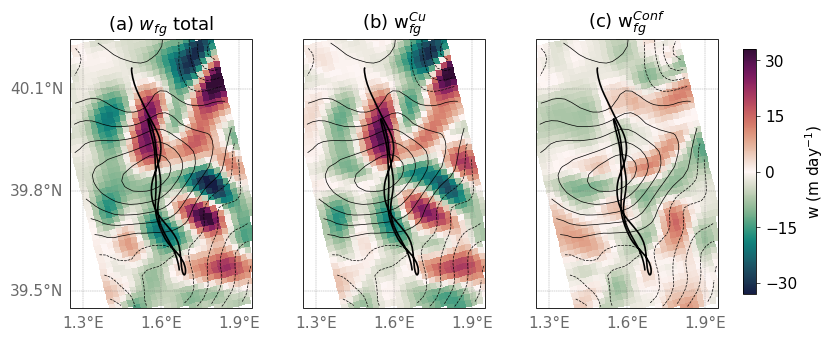

In [ ]:
# ==============================================================
# FIGURE 7 — w_fg DECOMPOSITION: total, curvature, confluence (300 m)
# ==============================================================
proj = ccrs.Mercator()
data_crs = ccrs.PlateCarree()
vmin, vmax = -33, 33  # m/day
iz = iz_fig7

fig, axs = plt.subplots(
    1, 3, figsize=(9, 3.5),
    subplot_kw={'projection': proj},
    gridspec_kw={'wspace': 0.004, 'hspace': 0.2}
)

im = axs[0].pcolormesh(
    lon_i, lat_i, w_fg_filtered[iz] * 86400,
    cmap=cmocean.cm.curl, vmin=vmin, vmax=vmax,
    shading='auto', transform=data_crs
)
axs[0].set_title(r"(a) $w_{fg}$ total", fontsize=13)

axs[1].pcolormesh(
    lon_i, lat_i, w_curv_fg[iz] * 86400,
    cmap=cmocean.cm.curl, vmin=vmin, vmax=vmax,
    shading='auto', transform=data_crs
)
axs[1].set_title(rf"(b) w$_{{fg}}^{{Cu}}$", fontsize=13)

axs[2].pcolormesh(
    lon_i, lat_i, w_crst_fg[iz] * 86400,
    cmap=cmocean.cm.curl, vmin=vmin, vmax=vmax,
    shading='auto', transform=data_crs
)
axs[2].set_title(rf"(c) w$_{{fg}}^{{Conf}}$", fontsize=13)

cax = fig.add_axes([0.9, 0.15, 0.015, 0.7])
cb = plt.colorbar(im, cax=cax, orientation='vertical')
cb.set_label(r"w (m day$^{-1}$)", fontsize=11)
cb.set_ticks([-30,-15, 0, 15, 30])
cb.ax.tick_params(labelsize=11, length=3, width=0.5)

extent = [1.25, 1.95, 39.45, 40.25]
xticks_map = [1.3, 1.6, 1.9]
yticks_map = [39.5, 39.8, 40.1]

for ax in axs:
    ax.contour(lon_i, lat_i, ssh_i, levels=np.arange(-4, 4.1, 0.5),
               colors='k', linewidths=0.5, transform=data_crs)
    ax.plot(Lon09, Lat09, 'k-', lw=1.2, transform=data_crs)
    ax.coastlines(linewidth=0.6)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                      linestyle='--', color='dimgray', alpha=0.7)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(xticks_map)
    gl.ylocator = mticker.FixedLocator(yticks_map)
    gl.xlabel_style = {'size': 11, 'color':'dimgray'}
    gl.ylabel_style = {'size': 11, 'color':'dimgray'}

    if ax in [axs[1], axs[2]]:
        gl.left_labels = False

    ax.set_extent(extent, crs=ccrs.PlateCarree())

# plt.savefig(DIR_FIGURES + '/figure7.png', dpi=300, bbox_inches='tight')
plt.show()